## 1. Setup and Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
from scipy.stats import pearsonr
import matplotlib.ticker as mticker

## 2. Data Loading & Initial Inspection

We load the raw dataset into `raw_df` and immediately create `final_df` as the working copy. From this point on, `raw_df` is never modified, it always reflects the original CSV as provided.

In [3]:
raw_df = pd.read_csv("ai_productivity_dataset_final.csv")
final_df = raw_df.copy()

raw_df.info()
raw_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

(3248, 34)

### 2.1 .describe() results: Data Quality Checks

From the summary statistics, a few inconsistencies emerge:
- Some variables contain extreme values, such as `hours_spent` and `profit`, which show large outliers compared to their typical range.
- In addition, `billable_hours` includes negative values, which are not meaningful and likely due to data issues or adjustments.
- There are also differences in the number of available observations across variables, indicating the presence of missing values.

Overall, while most variables appear reasonable, some cleaning and careful handling of outliers may be needed before further analysis.

In [4]:
raw_df.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


### 2.2 Categorical Variables Overview

From the summary statistics, a few relevant points emerge.

`delivered_at` contains some missing values, which is expected since not all tasks may have been completed.

`jira_ticket` also contain missing values.

`task_id` is not fully unique, suggesting the presence of duplicated entries or multiple records per task.

Finally, `created_at` and `updated_at` have a relatively low number of unique values compared to the dataset size, indicating that many records share the same timestamps.

In [5]:
cat_df = raw_df.select_dtypes(exclude=["number"])
cat_df.describe()

,task_id,client,project_id,client_tier,team,task_type,seniority,deadline_pressure,pricing_model,created_at,delivered_at,ai_assisted,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
count,3248,3248,3248,3248,3248,3248,3248,3248,3248,3248,3210,3248,3248,3248,3248,3248,2909,3248,3248
unique,3200,28,64,3,15,29,3,3,3,330,335,2,119,338,6,5,2868,3,5
top,T00010,Client_G,P028,mid,Content,design,mid,medium,hourly,2026-03-27,2026-01-18,True,user_026,2026-03-01,in_progress,qa,JIRA-53111,false,v1
freq,2,415,77,1514,803,456,1296,1482,1561,22,19,2561,44,20,1129,687,2,1458,926


### 2.3 Duplicate & Identifier Check for `task_id`

We verify whether any rows are fully duplicated and whether `task_id` contains repeated values. Repeated `task_id` entries are inspected to determine if they belong to the same client (likely data versioning) or to different clients with the same task. 

Since there are 48 `task_id` repetition we want to check if there are duplicated rows in the whole dataset. 

In [6]:
# list of repeated task_id 
task_id_counts = final_df["task_id"].value_counts()
task_id_repeated = task_id_counts[task_id_counts == 2].index.tolist()
task_id_repeated


['T00010',
 'T00139',
 'T00170',
 'T00205',
 'T00219',
 'T00285',
 'T00343',
 'T00413',
 'T00460',
 'T00608',
 'T00617',
 'T00675',
 'T00721',
 'T00726',
 'T00748',
 'T00759',
 'T00875',
 'T00881',
 'T00885',
 'T01075',
 'T01080',
 'T01148',
 'T01151',
 'T01162',
 'T01236',
 'T01344',
 'T01359',
 'T01400',
 'T01476',
 'T01516',
 'T01740',
 'T01849',
 'T01852',
 'T01881',
 'T01915',
 'T01988',
 'T02060',
 'T02075',
 'T02118',
 'T02191',
 'T02295',
 'T02307',
 'T02344',
 'T02652',
 'T02689',
 'T02958',
 'T03121',
 'T03155']

In [7]:
#Verify that evry task_id of task_id_repeated belong to the same client
for task_id in task_id_repeated:
    client_ids = final_df[final_df["task_id"] == task_id]["client"].unique()
    if len(client_ids) > 1:
        print(f"Task ID {task_id} belongs to multiple clients: {client_ids}")
        

Task ID T00010 belongs to multiple clients: <StringArray>
['Client_F', 'Client_J']
Length: 2, dtype: str
Task ID T00726 belongs to multiple clients: <StringArray>
['Client_[', 'Client_F']
Length: 2, dtype: str
Task ID T00875 belongs to multiple clients: <StringArray>
['Client_C', 'Client_W']
Length: 2, dtype: str
Task ID T01080 belongs to multiple clients: <StringArray>
['Client_D', 'Client_M']
Length: 2, dtype: str
Task ID T01740 belongs to multiple clients: <StringArray>
['Client_A', 'Client_S']
Length: 2, dtype: str
Task ID T02295 belongs to multiple clients: <StringArray>
['Client_W', 'Client_K']
Length: 2, dtype: str


In [8]:
final_df.shape

(3248, 34)

After speaking with the company, we concluded that `task_id` with different clients were due to a typo. So we decided to drop all the 12 rows. 

In [9]:
#drop task_id row with task_id == T00010, T00726, T00875, T01080, T01740 and T02295
final_df = final_df[~final_df["task_id"].isin(["T00010", "T00726", "T00875", "T01080", "T01740", "T02295"])]    

print(len(final_df))

3236


In [10]:
# checking if there are duplicated rows
print("Number of duplicated rows:", final_df.duplicated().sum())

Number of duplicated rows: 0


## 3. Categorical Variable Cleaning

Several categorical columns contain label inconsistencies (typos, mixed case, alternate naming conventions). We standardise each one before any analysis.

### 3.1 `team`

Lowercasing, stripping whitespace,correcting typos (`contennt` → `content`, `desgn` → `design` ) and merging `Paid_Media` with `Media`.

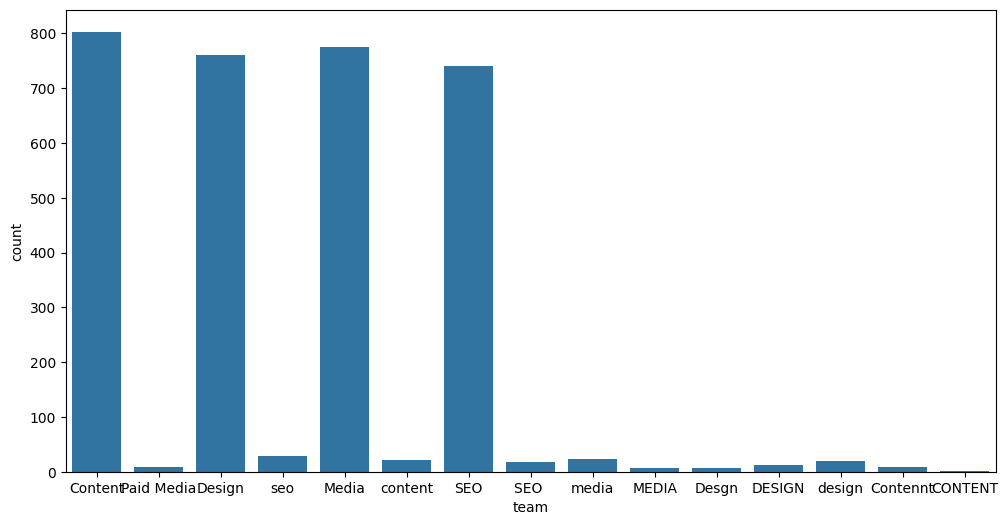

In [11]:
# visualization of team's inconsistencies
plt.figure(figsize=(12,6))
sns.countplot(data = final_df, x = "team")
plt.show()

In [12]:
final_df["team"].value_counts()

# team is used to classify the different teams working on the projects
# we can obsserve that there are some repetitions and errors so we need to fix them

final_df["team"] = final_df["team"].str.lower()
final_df["team"] = final_df["team"].str.strip()   

# We need to convert the value "contennt" to "content" in the team name column. 
# We do the same for design
final_df["team"] = final_df["team"].replace("contennt", "content")
final_df["team"] = final_df["team"].replace("desgn", "design")

# paid_media has significantly fewer observations than media merging into media 
final_df["team"] = final_df["team"].replace("paid media", "media") 
final_df["team"].value_counts()

team
content    835
media      815
design     798
seo        788
Name: count, dtype: int64

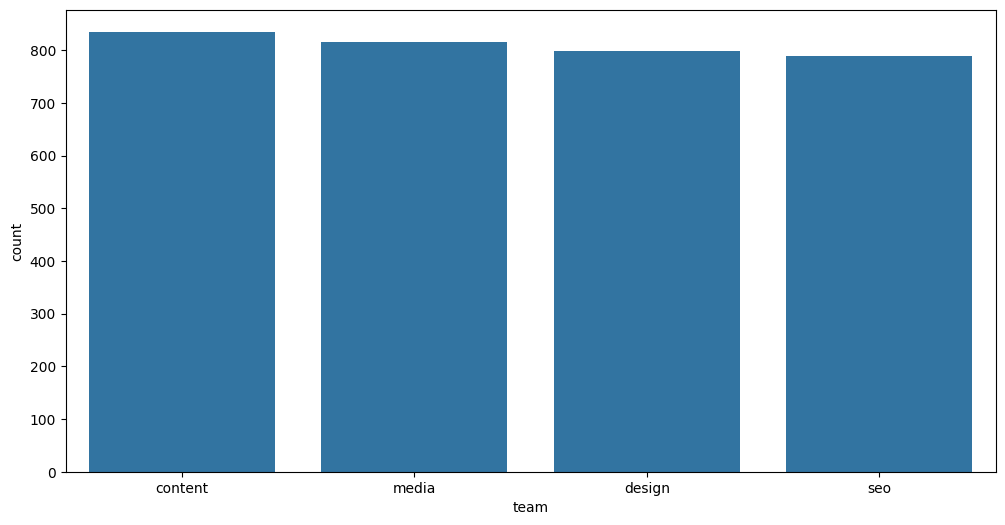

In [13]:
# checking the results
plt.figure(figsize=(12,6))
sns.countplot(data = final_df, x = "team")
plt.show()

### 3.2 `task_type`

Lowercasing, stripping and merging low-frequency subcategories into their parent categories.

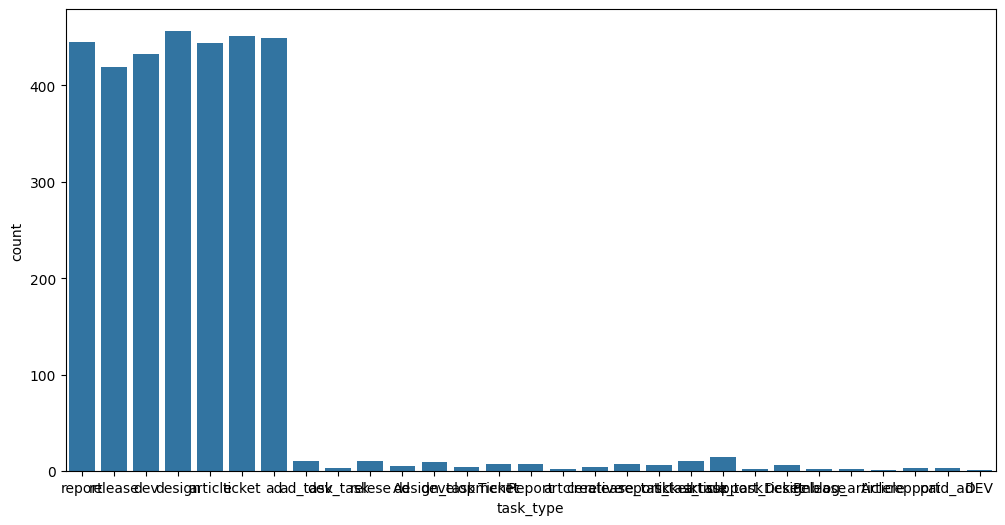

In [14]:
# visualization of task_type inconsistencies
plt.figure(figsize=(12,6))
sns.countplot(data = final_df, x = "task_type")
plt.show()

In [15]:
# we need to clean the task_type column as well
final_df["task_type"] = final_df["task_type"].str.lower()
final_df["task_type"] = final_df["task_type"].str.strip()

final_df["task_type"] = final_df["task_type"].replace("relese", "release")
final_df["task_type"] = final_df["task_type"].replace("release_task", "release")
final_df["task_type"] = final_df["task_type"].replace("dev_task", "dev")
final_df["task_type"] = final_df["task_type"].replace("ad_task", "ad")
final_df["task_type"] = final_df["task_type"].replace("article_task", "article")
final_df["task_type"] = final_df["task_type"].replace("artcle", "article")
final_df["task_type"] = final_df["task_type"].replace("repport", "report")
final_df["task_type"] = final_df["task_type"].replace("report_task", "report")
final_df["task_type"] = final_df["task_type"].replace("design_task", "design")
final_df["task_type"] = final_df["task_type"].replace("ticket_task", "ticket")
final_df["task_type"] = final_df["task_type"].replace("dev", "development")

In [16]:
# merge low-frequency subcategories into their parent categories  
final_df["task_type"] = final_df["task_type"].replace("blog_article", "article")  
final_df["task_type"] = final_df["task_type"].replace("paid_ad", "ad")  
final_df["task_type"] = final_df["task_type"].replace("support_ticket", "ticket")  
final_df["task_type"] = final_df["task_type"].replace("creative", "design")  
final_df["task_type"].value_counts()

task_type
design         478
ticket         473
ad             470
article        466
report         464
development    444
release        441
Name: count, dtype: int64

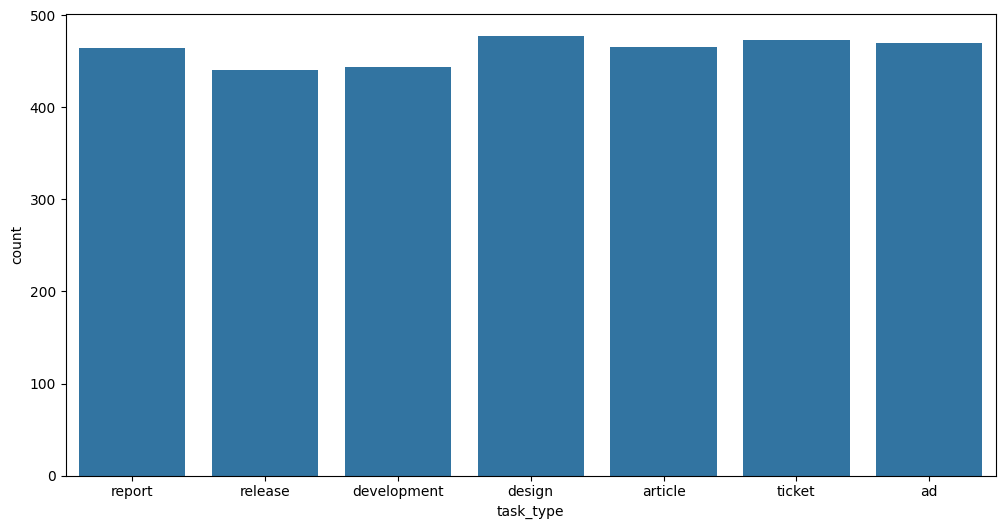

In [17]:
# checking the results
plt.figure(figsize=(12,6))
sns.countplot(data = final_df, x = "task_type")
plt.show()

### 3.3 Remaining Variables: Value Inspection

No cleaning was required for the remaining categorical columns. We inspect them to confirm label consistency and understand their distributions.

In [18]:
final_df["client_tier"].value_counts()

client_tier
mid     1508
low      873
high     855
Name: count, dtype: int64

In [19]:
final_df["seniority"].value_counts()

seniority
mid       1290
junior    1184
senior     762
Name: count, dtype: int64

In [20]:
final_df["deadline_pressure"].value_counts()

deadline_pressure
medium    1478
low        912
high       846
Name: count, dtype: int64

In [21]:
final_df["pricing_model"].value_counts()

pricing_model
hourly         1557
fixed          1219
value_based     460
Name: count, dtype: int64

In [22]:
final_df["task_status"].value_counts()

task_status
in_progress    1123
review          864
delivered       766
draft           182
archived        151
blocked         150
Name: count, dtype: int64

In [23]:
final_df["workflow_stage"].value_counts()

workflow_stage
qa               687
client_review    660
finalized        643
briefing         636
execution        610
Name: count, dtype: int64

In [24]:
final_df["content_version"].value_counts()

content_version
v1       922
v2       774
v3       662
final    559
v4       319
Name: count, dtype: int64

In [25]:
final_df["legacy_ai_flag"].value_counts()

legacy_ai_flag
false      1454
true       1445
unknown     337
Name: count, dtype: int64

In [26]:
final_df["scope_change_flag"].value_counts()  

scope_change_flag
0    2784
1     452
Name: count, dtype: int64

In [27]:
final_df["sla_breach"].value_counts()

sla_breach
0    1949
1    1287
Name: count, dtype: int64

In [28]:
final_df["jira_ticket"].value_counts()

jira_ticket
JIRA-53111    2
JIRA-67759    2
JIRA-38743    2
JIRA-62438    2
JIRA-36863    2
             ..
JIRA-88330    1
JIRA-42947    1
JIRA-90491    1
JIRA-32851    1
JIRA-39958    1
Name: count, Length: 2857, dtype: int64

This is how we interpreted these variables: 

- **client_tier**  
  Used to classify the "importance" of clients based on their value and the revenue they generate.

- **legacy_ai_flag**  
  A boolean variable: it is *True* if the task was performed using older generation AI tools.

- **scope_change_flag**  
  Indicates whether the scope of the task changed during its execution.

- **jira_ticket**  
  A unique identifier that links each task to its corresponding record in the Jira system.  
  About **10% of the values are missing**, meaning those tasks were not tracked in Jira.  
  Since this variable is only an identifier and does not provide useful predictive information, it was **excluded from further analysis**.

## 4. Date Variables Conversion

The columns `created_at`, `delivered_at`, and `updated_at` are stored as strings and must be converted to datetime objects to enable time-based feature engineering.

In [29]:
# We need to convert "created_at", "delivered_at" and "updated_at" to datetime since they are str
# errors = "coerce" will convert any value that cannot be parsed to datetime to NaT (Not a Time) instead of raising an error.
final_df["created_at"] = pd.to_datetime(final_df["created_at"], errors="coerce")    
final_df["delivered_at"] = pd.to_datetime(final_df["delivered_at"], errors="coerce")
final_df["updated_at"] = pd.to_datetime(final_df["updated_at"], errors="coerce")
final_df[["created_at", "delivered_at", "updated_at"]].head()

,created_at,delivered_at,updated_at
0,2025-11-20,2025-11-25,2025-11-28
1,2026-01-24,2026-01-26,2026-01-26
2,2025-09-16,2025-09-23,2025-09-17
3,2025-11-06,2025-11-09,2025-11-12
4,2026-05-02,2026-05-06,2026-05-09


## 5. Missing Value Treatment

We first visualise the overall missing value pattern, then treat each affected column individually with a justified imputation strategy.

The columns that contain missing are: `brief_quality_score`, `delivered_at`, `sla_days`, `billable_hours`, `ai_usage_pct`, `rework_hours`, `outcome_score` and `jira_ticket`.

In [30]:
# checking the missing values for each column
missing_values = final_df.isnull().sum()
missing_percentage = (missing_values / final_df.shape[0]) * 100

missing_summary = pd.DataFrame({"count": missing_values, "pct": missing_percentage})
missing_summary[missing_summary["count"] > 0]

,count,pct
brief_quality_score,68,2.101360
delivered_at,38,1.174289
sla_days,36,1.112485
billable_hours,82,2.533993
ai_usage_pct,143,4.419036
rework_hours,72,2.224969
outcome_score,132,4.079110
jira_ticket,339,10.475896


<Axes: >

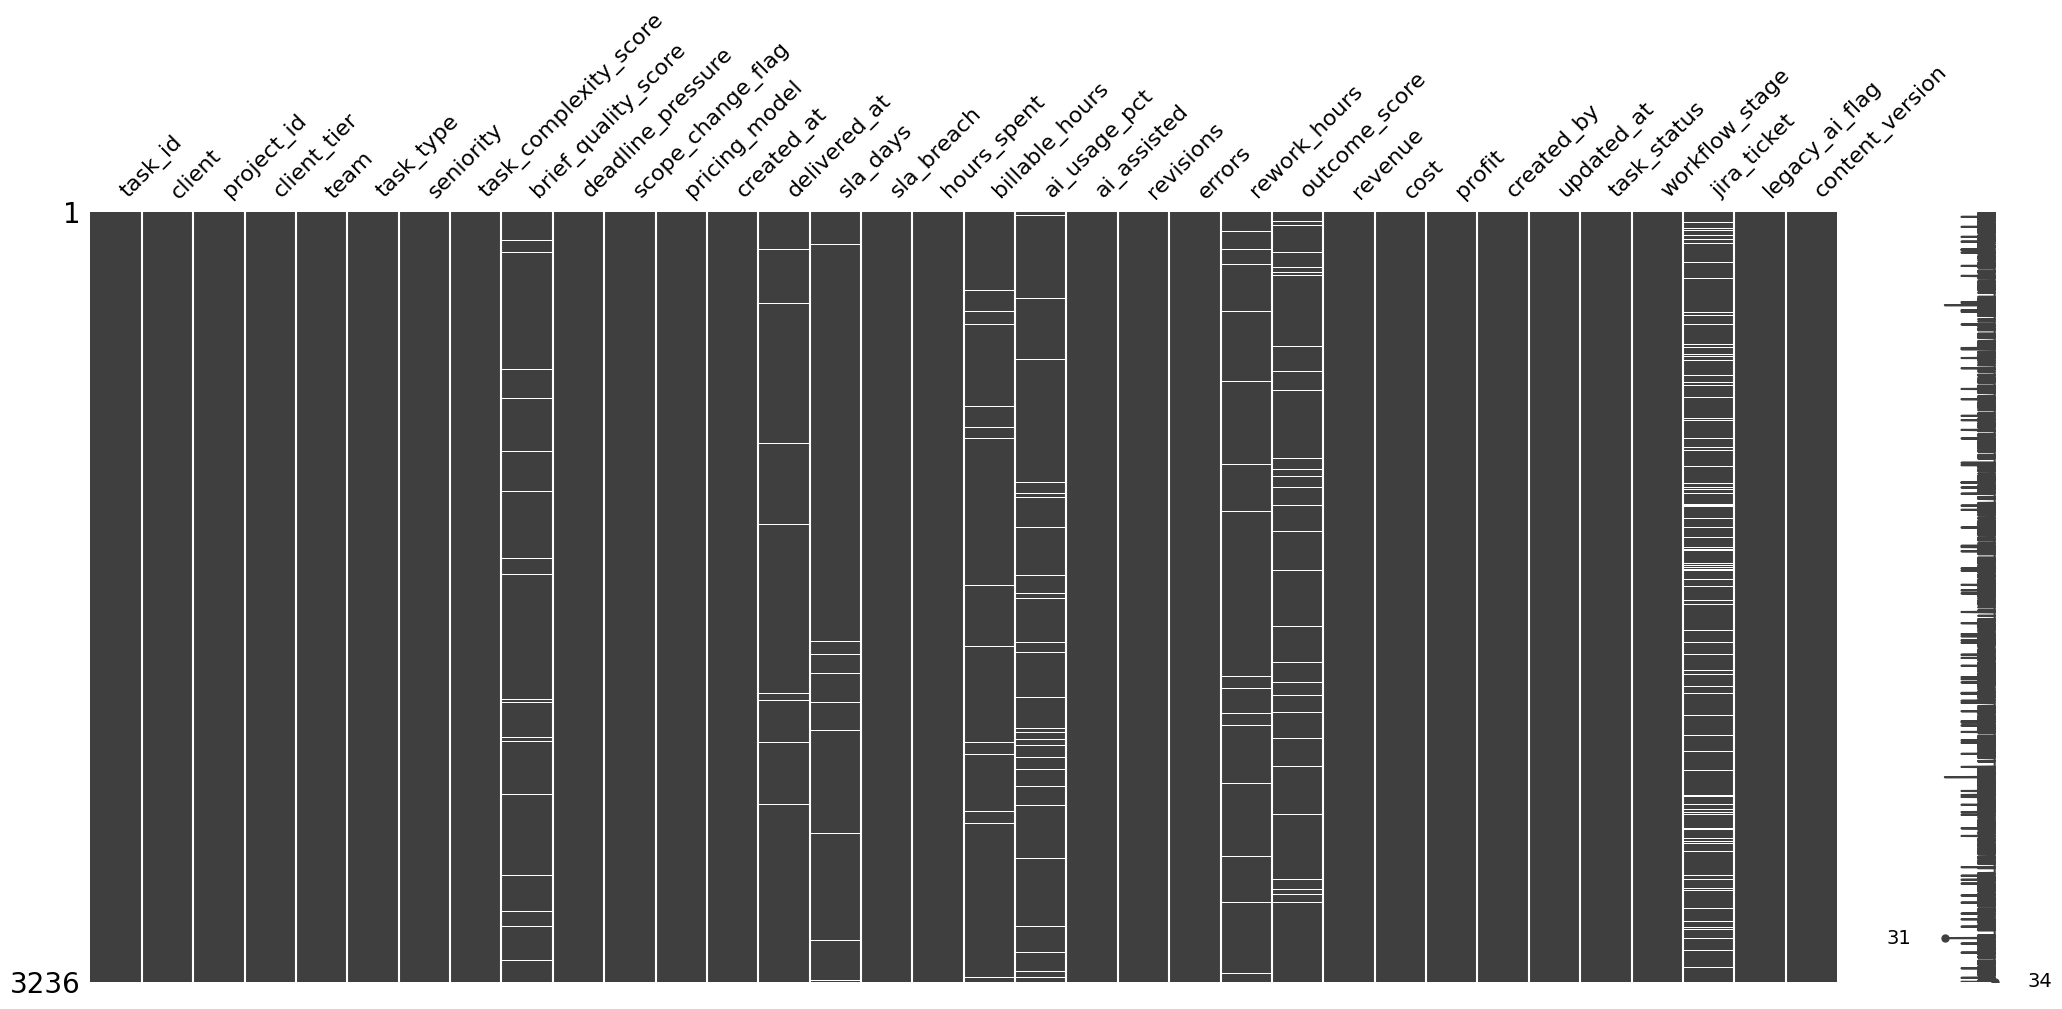

In [31]:
# visualization of columns that contain missing values
msno.matrix(final_df)

### 5.1 Handling missing values with Median imputation (MCAR)

`brief_quality_score`

~2.1% of values are missing.

An analysis comparing missing vs non missing observations showed that missing values are almost completely at random (MCAR) as they are associated with very little differences in variables such as task duration, SLA breach and scope.

In [32]:
final_df["missing_flag"] = final_df["brief_quality_score"].isna().astype(int)
final_df.groupby("missing_flag").mean(numeric_only=True)

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
missing_flag,,,,,,,,,,,,,,,,
0,2.871843,3.183396,0.138258,5.005426,0.396780,13.032013,8.455922,0.362045,0.789141,3.011364,1.020833,2.429922,68.851810,1121.529146,773.489592,348.039553
1,2.676471,NaN,0.205882,5.238806,0.441176,12.227324,7.242687,0.343636,0.750000,2.750000,0.794118,2.636820,70.056308,1109.192658,666.927794,442.264864


In [33]:
final_df["brief_quality_score"] = final_df["brief_quality_score"].fillna(final_df["brief_quality_score"].median())

`sla_days`

We can inpute sla_days missings with the median since the missings are completely at random.

In [34]:
final_df["missing_flag"] = final_df["sla_days"].isna().astype(int)
final_df.groupby("missing_flag").mean(numeric_only=True)

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
missing_flag,,,,,,,,,,,,,,,,
0,2.869063,3.178125,0.138750,5.010313,0.396562,13.028002,8.438147,0.362451,0.789375,3.011250,1.018438,2.434339,68.861317,1123.492854,769.904097,353.588757
1,2.750000,3.305556,0.222222,NaN,0.500000,11.868611,7.717429,0.287576,0.694444,2.527778,0.805556,2.431143,70.216389,923.675000,890.916909,32.758091


In [35]:
final_df["sla_days"] = final_df["sla_days"].fillna(final_df["sla_days"].median())

`ai_usage_pct`

~4.5% of values are missing. 

An analysis of `ai_usage_pct` within tasks where `legacy_ai_flag` == true shows a median value of 0.34%.  
This clearly indicates that AI was already being used even in so-called "legacy" tasks.

Therefore, the `legacy_ai_flag` does not imply the absence of AI usage. 
Instead, it reflects the use of older-generation AI tools.

Missing values in `ai_usage_pct` should not be interpreted as zero usage of AI, but rather as missing or unrecorded information.

In [36]:
final_df[final_df["legacy_ai_flag"] == "true"]["ai_usage_pct"].describe()

count    1376.000000
mean        0.365494
std         0.202027
min         0.010000
25%         0.200000
50%         0.340000
75%         0.502500
max         0.930000
Name: ai_usage_pct, dtype: float64

In [37]:
final_df["missing_flag"] = final_df["ai_usage_pct"].isna().astype(int)
final_df.groupby("missing_flag").mean(numeric_only=True)

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
missing_flag,,,,,,,,,,,,,,,,
0,2.864533,3.186874,0.13967,4.998060,0.396379,12.960391,8.411403,0.361652,0.788231,3.002263,1.016812,2.407951,68.871032,1125.543670,769.502118,356.041552
1,2.937063,3.020979,0.13986,5.272727,0.426573,14.198511,8.836763,NaN,0.790210,3.083916,1.000000,3.012160,69.004071,1028.831204,809.063406,219.767798


In [38]:
final_df["ai_usage_pct"] = final_df["ai_usage_pct"].fillna(final_df["ai_usage_pct"].median())

`rework_hours` 

~2.2% of values are missing. 

When the missing valued of `rework_hours` correspond to `errors = 0` and `revisions = 0`, we impute missing values with zero. For the other cases we assume that imputing missing values with the median is sufficient. 

In [39]:
# checking rework_hours missing values when errors = 0 and revisions = 0
print("Number of rows where err = 0 and rev = 0:",final_df[(final_df["errors"] == 0) & (final_df["revisions"] == 0)]["rework_hours"].isna().sum())

Number of rows where err = 0 and rev = 0: 3


In [40]:
final_df[final_df["rework_hours"].isna()][["errors", "revisions","task_status", "outcome_score"]].head(50)

,errors,revisions,task_status,outcome_score
47,1,3,in_progress,77.98
82,0,2,in_progress,68.17
89,2,4,delivered,55.63
138,0,4,review,71.45
158,0,3,delivered,86.61
160,0,4,in_progress,75.92
176,4,1,in_progress,79.97
203,1,0,delivered,43.72
219,0,7,delivered,73.94
221,1,1,delivered,55.59


In [41]:
# substitute missing values of rework_hours with zero if errors = 0 and revisions = 0
mask = (final_df["errors"] == 0) & (final_df["revisions"] == 0) & (final_df["rework_hours"].isna())
final_df.loc[mask, "rework_hours"] = 0

print(f"Remaining missing values in rework_hours: {final_df['rework_hours'].isna().sum()}")

Remaining missing values in rework_hours: 69


In [42]:
final_df["rework_hours"] = final_df["rework_hours"].fillna(final_df["rework_hours"].median())

`outcome_score` 

Missing `outcome_score` does not depend on `task_status` or `workflow_stage`, confirming MCAR.

In [43]:
final_df.groupby("task_status")["outcome_score"].describe()
final_df[final_df["outcome_score"].isna()][["task_status", "workflow_stage", "delivered_at"]].head(10)

,task_status,workflow_stage,delivered_at
3,in_progress,briefing,2025-11-09
4,review,execution,2026-05-06
17,review,briefing,2025-12-10
21,in_progress,execution,2026-04-15
40,in_progress,execution,2025-07-04
57,delivered,execution,2025-11-28
171,archived,execution,2026-03-26
190,in_progress,finalized,2026-01-12
195,review,execution,2026-03-18
223,delivered,execution,2025-08-22


In [44]:
final_df["outcome_score"] = final_df["outcome_score"].fillna(final_df["outcome_score"].median())

`billable_hours` - Group-based median imputation

~2.5% of values are missing. Inspection confirms these are true missing values, not zero-billable tasks. A group-based median imputation by `pricing_model` and `task_type` is applied to preserve business structure.

In [45]:
final_df[final_df["billable_hours"].isna()][["task_status", "pricing_model", "hours_spent", "revenue", "cost", "profit"]].head(10)

,task_status,pricing_model,hours_spent,revenue,cost,profit
55,in_progress,fixed,7.34,1024.79,292.57,732.22
105,review,hourly,7.51,1588.92,472.46,1116.46
132,in_progress,fixed,0.02,1873.05,704.27,1168.78
148,review,hourly,9.85,230.11,404.81,-174.70
159,delivered,hourly,13.46,636.07,904.19,-268.12
189,in_progress,hourly,16.27,1141.32,1351.51,-210.19
269,delivered,fixed,24.38,1860.74,1365.13,495.61
279,in_progress,fixed,12.27,1262.77,1046.71,216.06
330,in_progress,fixed,27.99,770.29,2417.62,-1647.33
407,review,hourly,12.18,686.25,756.15,-69.90


In [46]:
group_median = final_df.groupby(["pricing_model", "task_type"])["billable_hours"].transform("median")
final_df["billable_hours"] = final_df["billable_hours"].fillna(group_median)
print((final_df["billable_hours"].isna().sum()))

0


### 5.2 `delivered_at` - True missing (for now no imputation)

We check whether missing values in `delivered_at` are due to errors or simply tasks not yet delivered. Since tasks not marked as delivered can still have a valid `delivered_at`, the missingness appears to be genuine.
We do not handle it at this stage. The few inconsistent cases (tasks marked as delivered but with missing `delivered_at`) will be addressed later when computing delivery time, by imputing `delivered_at` using the average delivery duration.

In [47]:
missing_values = final_df[final_df["delivered_at"].isnull()]["task_status"].value_counts()
missing_values

task_status
delivered      13
in_progress    12
review          7
archived        4
blocked         1
draft           1
Name: count, dtype: int64

In [48]:
final_df[final_df["task_status"] != "delivered"]["delivered_at"].notna().sum()

np.int64(2445)

### 5.3 Final Missing Value Check

After all imputations, we verify that no treatable missing values remain.

In [49]:
missing_values = final_df.isnull().sum()
missing_values[missing_values > 0]

delivered_at     38
jira_ticket     339
dtype: int64

## 6. Exploratory Data Analysis (EDA)

We explore distributions and relationships through a correlation heatmap, histograms of key numeric variables, countplots for categorical variables, and boxplots comparing categories against the main outcome variables.

Positive correlations:
- `billable_hours` and `cost` (0.55), 
- `ai_usage_pct` and `ai_assisted`(0.64) 
-  `revenue ` and `profit` (0.77)
Negative correlations: 
- `sla_days` and `sla_breach` (-0.62)  
- `errors` and `outcome_score`(-0.47)
- `cost` and `profit` (-0.41)

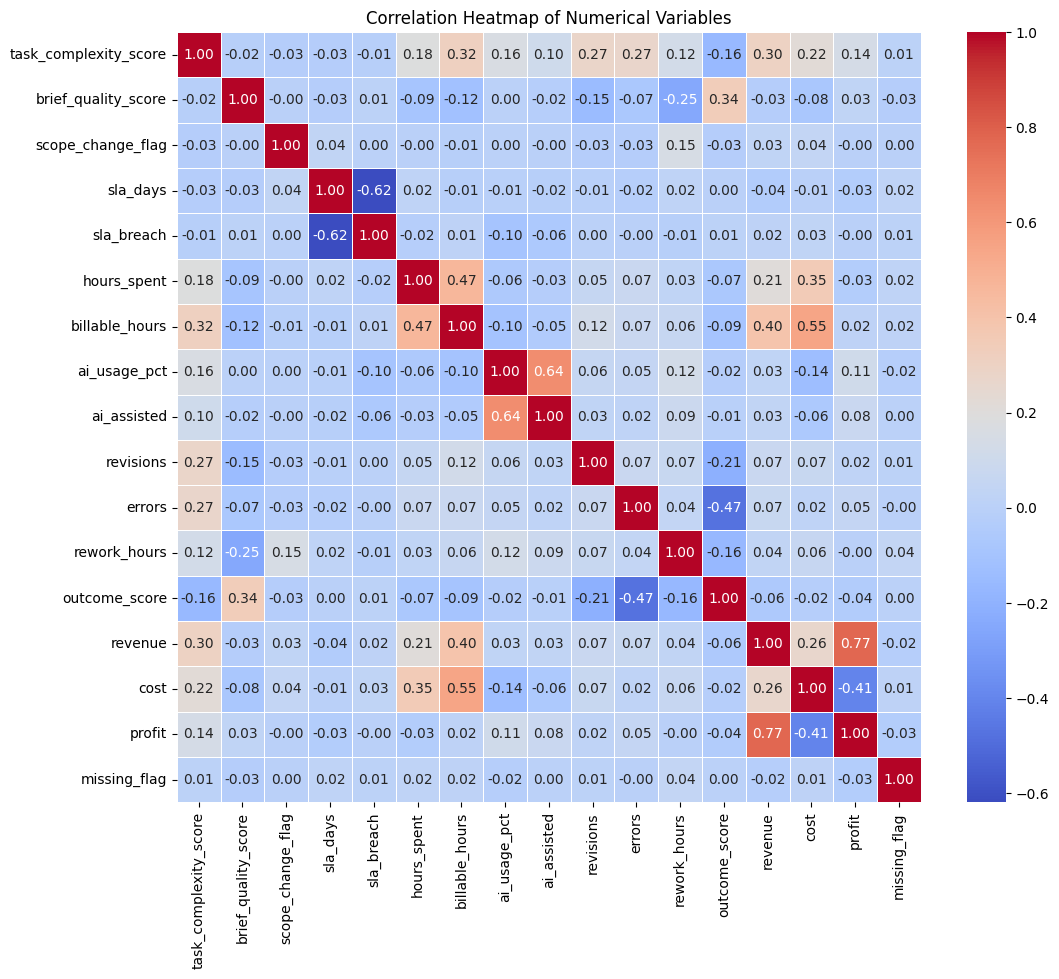

In [50]:
#heatmap of correlation between numerical variables
plt.figure(figsize=(12, 10))
sns.heatmap(final_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### 6.1 Numerical Variables 

In [51]:
num_cols = final_df.select_dtypes(include=np.number).columns.tolist()
num_cols

['task_complexity_score',
 'brief_quality_score',
 'scope_change_flag',
 'sla_days',
 'sla_breach',
 'hours_spent',
 'billable_hours',
 'ai_usage_pct',
 'revisions',
 'errors',
 'rework_hours',
 'outcome_score',
 'revenue',
 'cost',
 'profit',
 'missing_flag']

Distribution of `hours_spent`, `revenue`, `ai_usage_pct`, `rework_hours`, `outcome_score`, `cost` and `profit`.

Distribution observations:
- The variables `hours_spent`, `billable_hours`, `rework_hours`, `revenue`, and `cost` show strong right-skewness with obvious outliers. A log transformation may be necessary before modeling.
- `outcome_score` has an approximately left-normal distribution, suitable as a target variable.
- `profit` has a bimodal distribution with both positive and negative values, suggesting the existence of structurally different task segments.

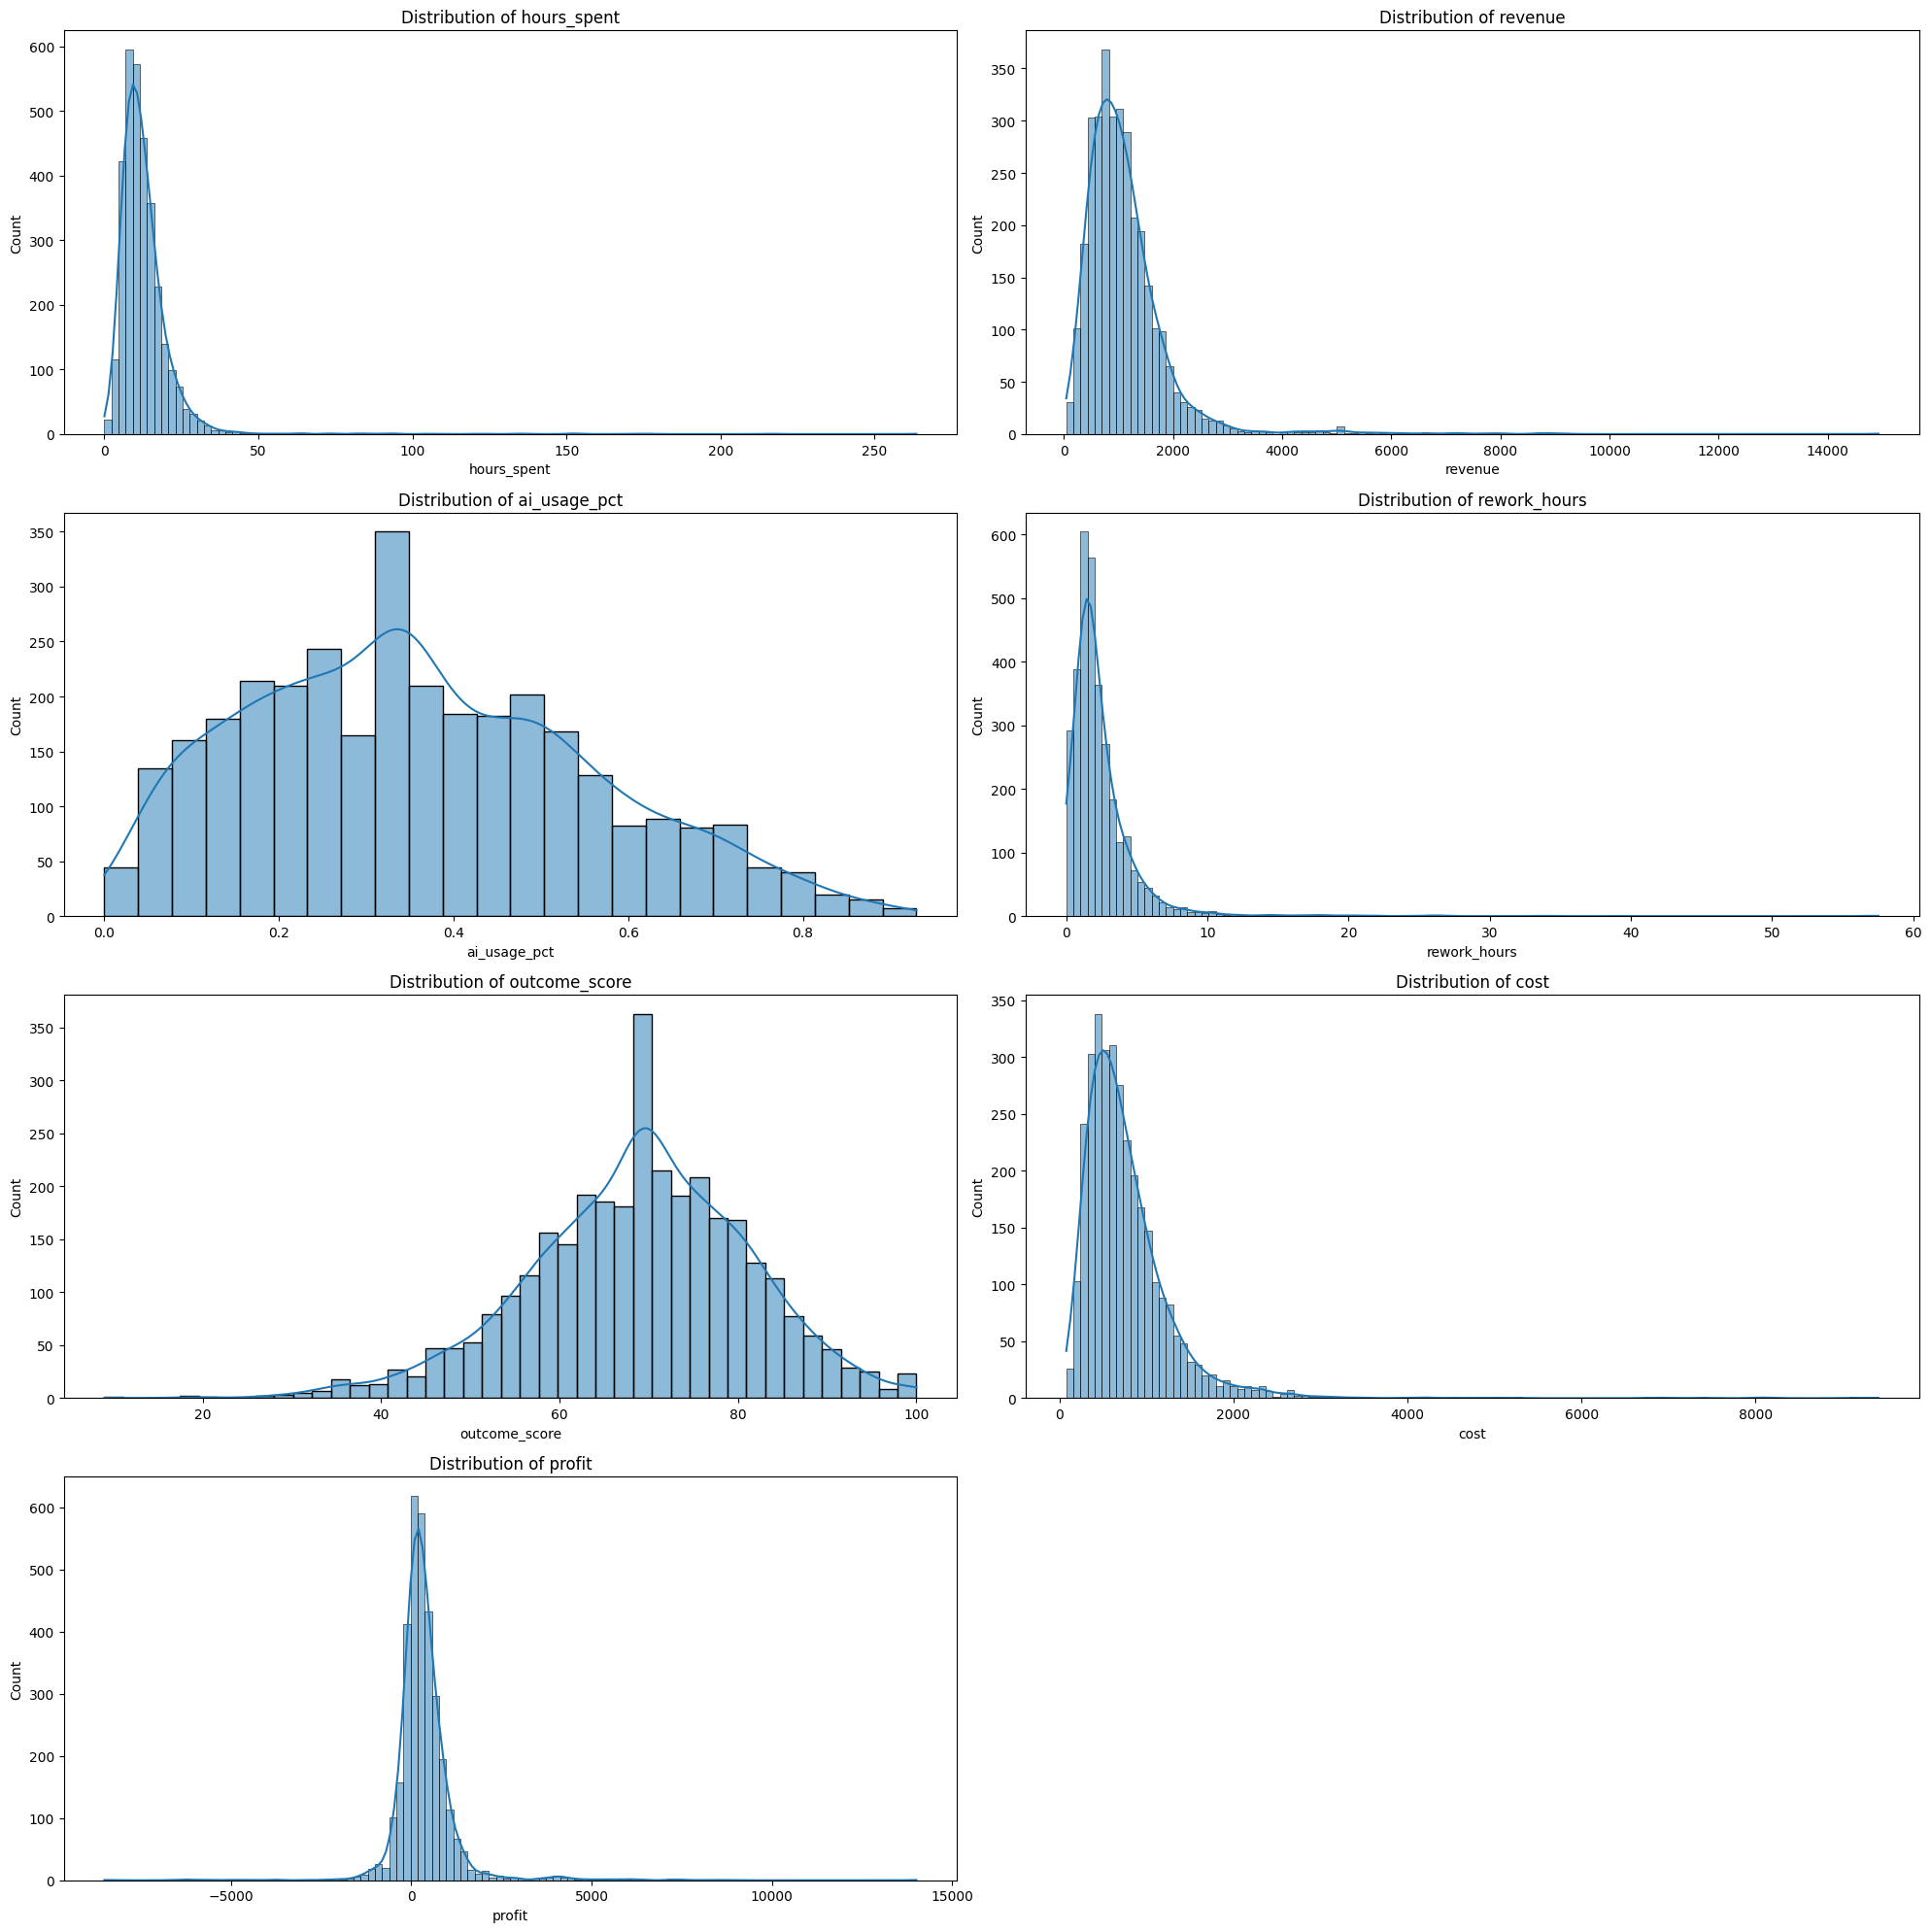

In [52]:
plt.figure(figsize=(20, 20))
cols_to_plot = ["hours_spent", "revenue", "ai_usage_pct", "rework_hours", "outcome_score", "cost", "profit"]
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 2, i + 1)
    sns.histplot(final_df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Boxplot for numerical columns for a final check

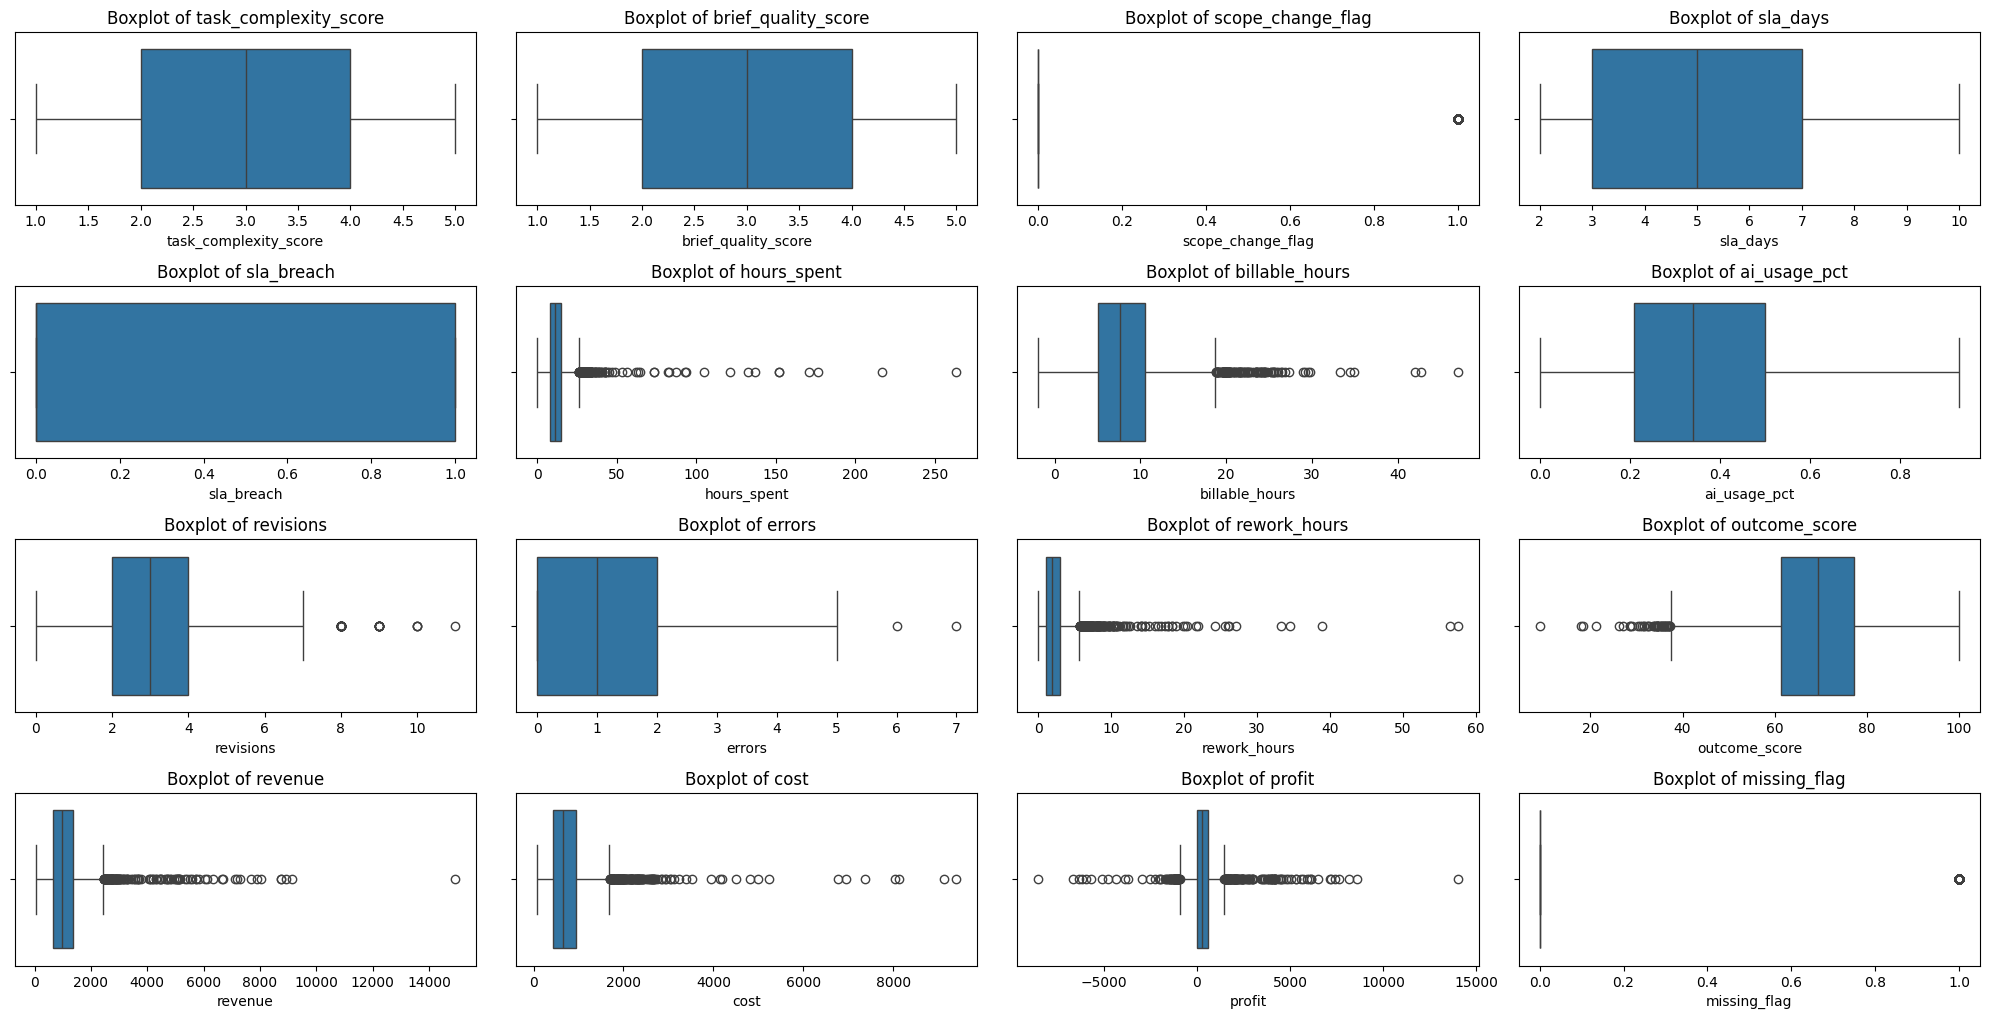

In [53]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols):
    plt.subplot(8, 4, i + 1)
    sns.boxplot(x=final_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

### 6.2 Categorical Variables 

In [54]:
cat_cols = final_df.select_dtypes(exclude=np.number).columns.tolist()
cat_cols

['task_id',
 'client',
 'project_id',
 'client_tier',
 'team',
 'task_type',
 'seniority',
 'deadline_pressure',
 'pricing_model',
 'created_at',
 'delivered_at',
 'ai_assisted',
 'created_by',
 'updated_at',
 'task_status',
 'workflow_stage',
 'jira_ticket',
 'legacy_ai_flag',
 'content_version']

In [55]:
cat_cols = ["team", "task_type", "seniority", "task_status", 
            "workflow_stage", "client_tier", "pricing_model", 
            "deadline_pressure", "ai_assisted", "legacy_ai_flag",
            "scope_change_flag", "content_version"]

Distribution of Categorical Variables

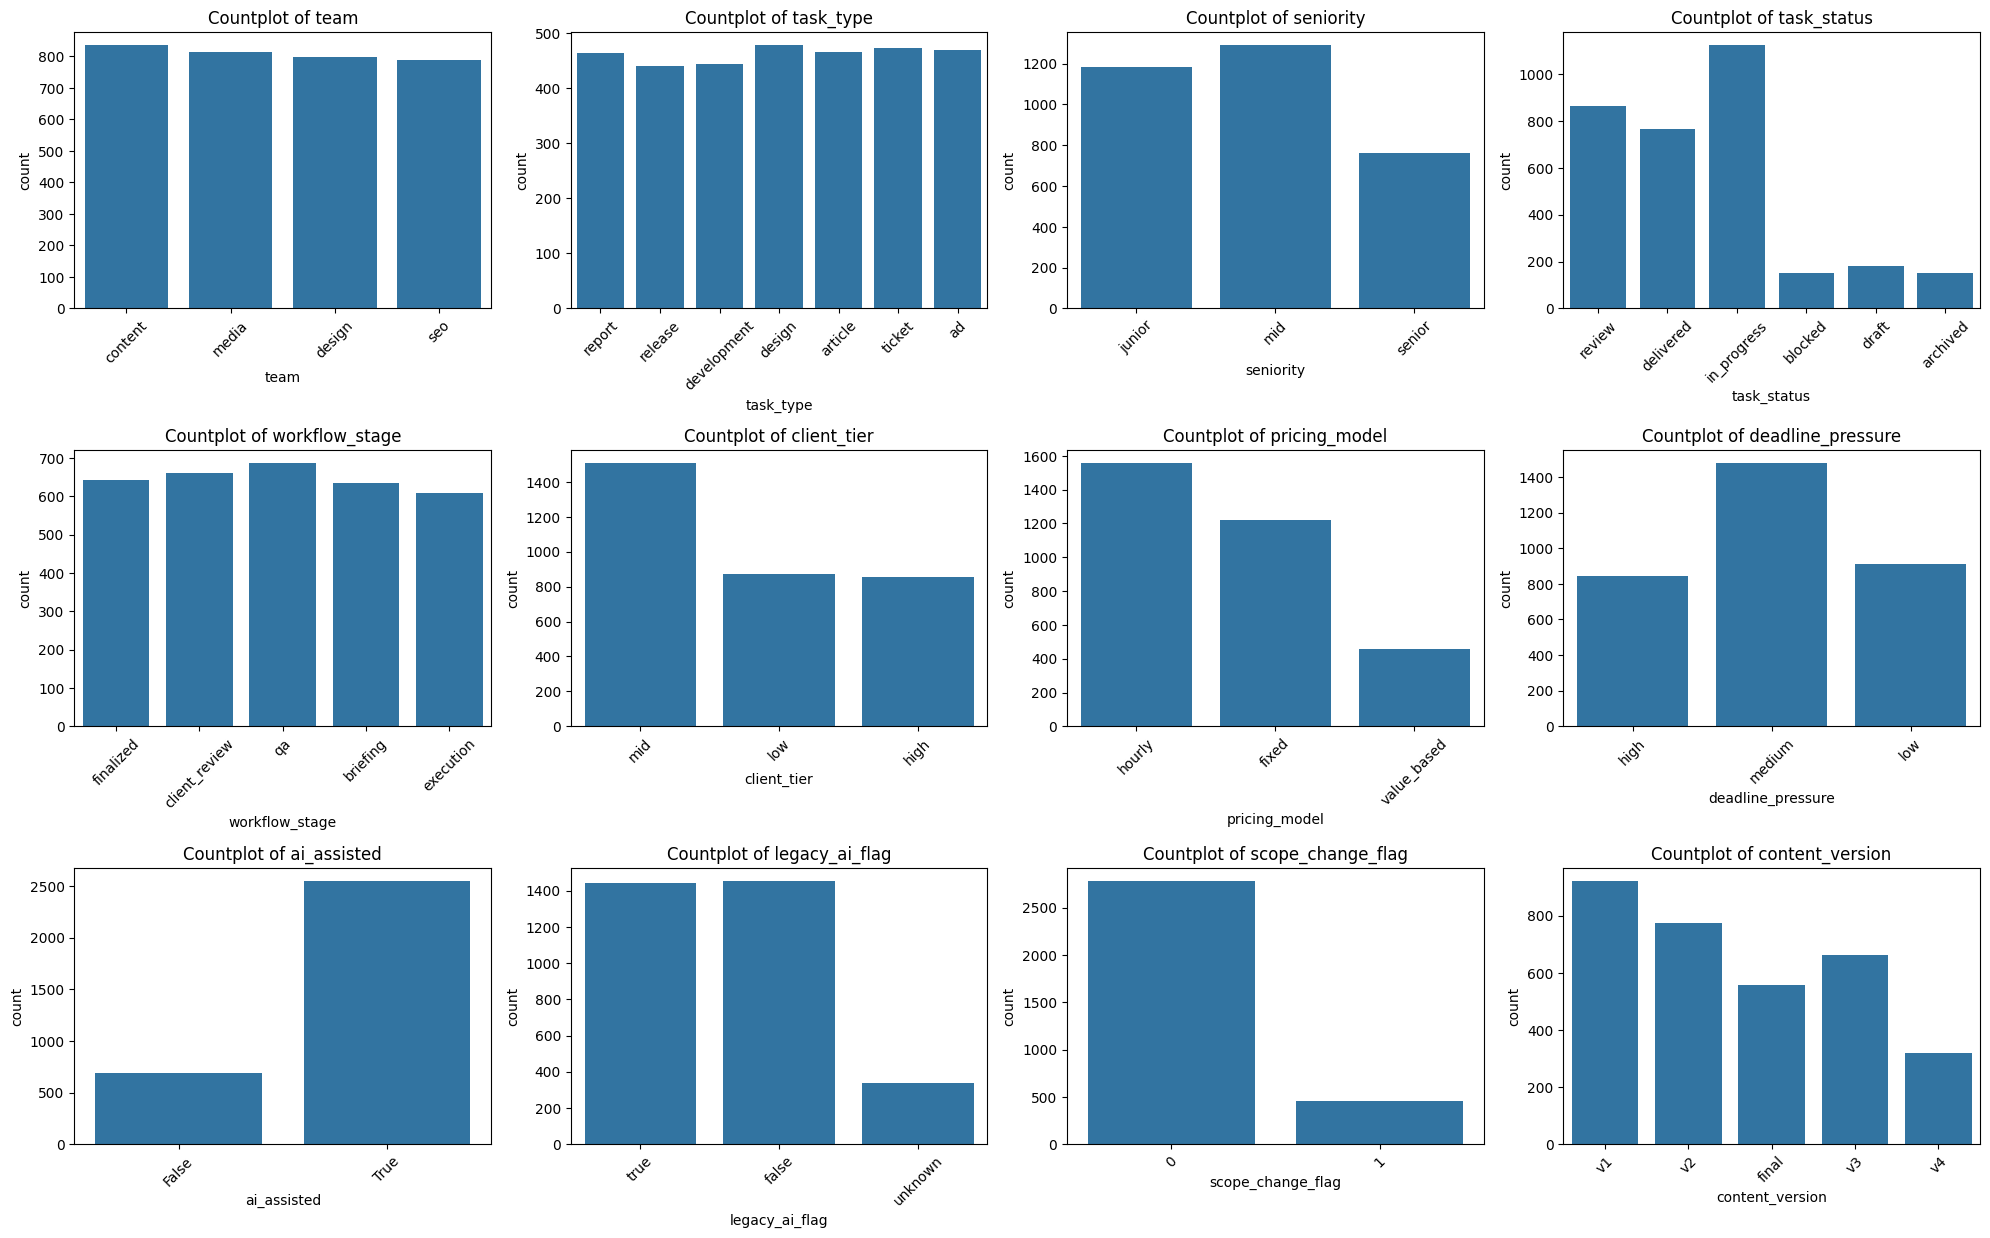

In [56]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.countplot(data=final_df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)     
plt.tight_layout()
plt.show()

Boxplot for categorical variables on `ai_usage_pct`

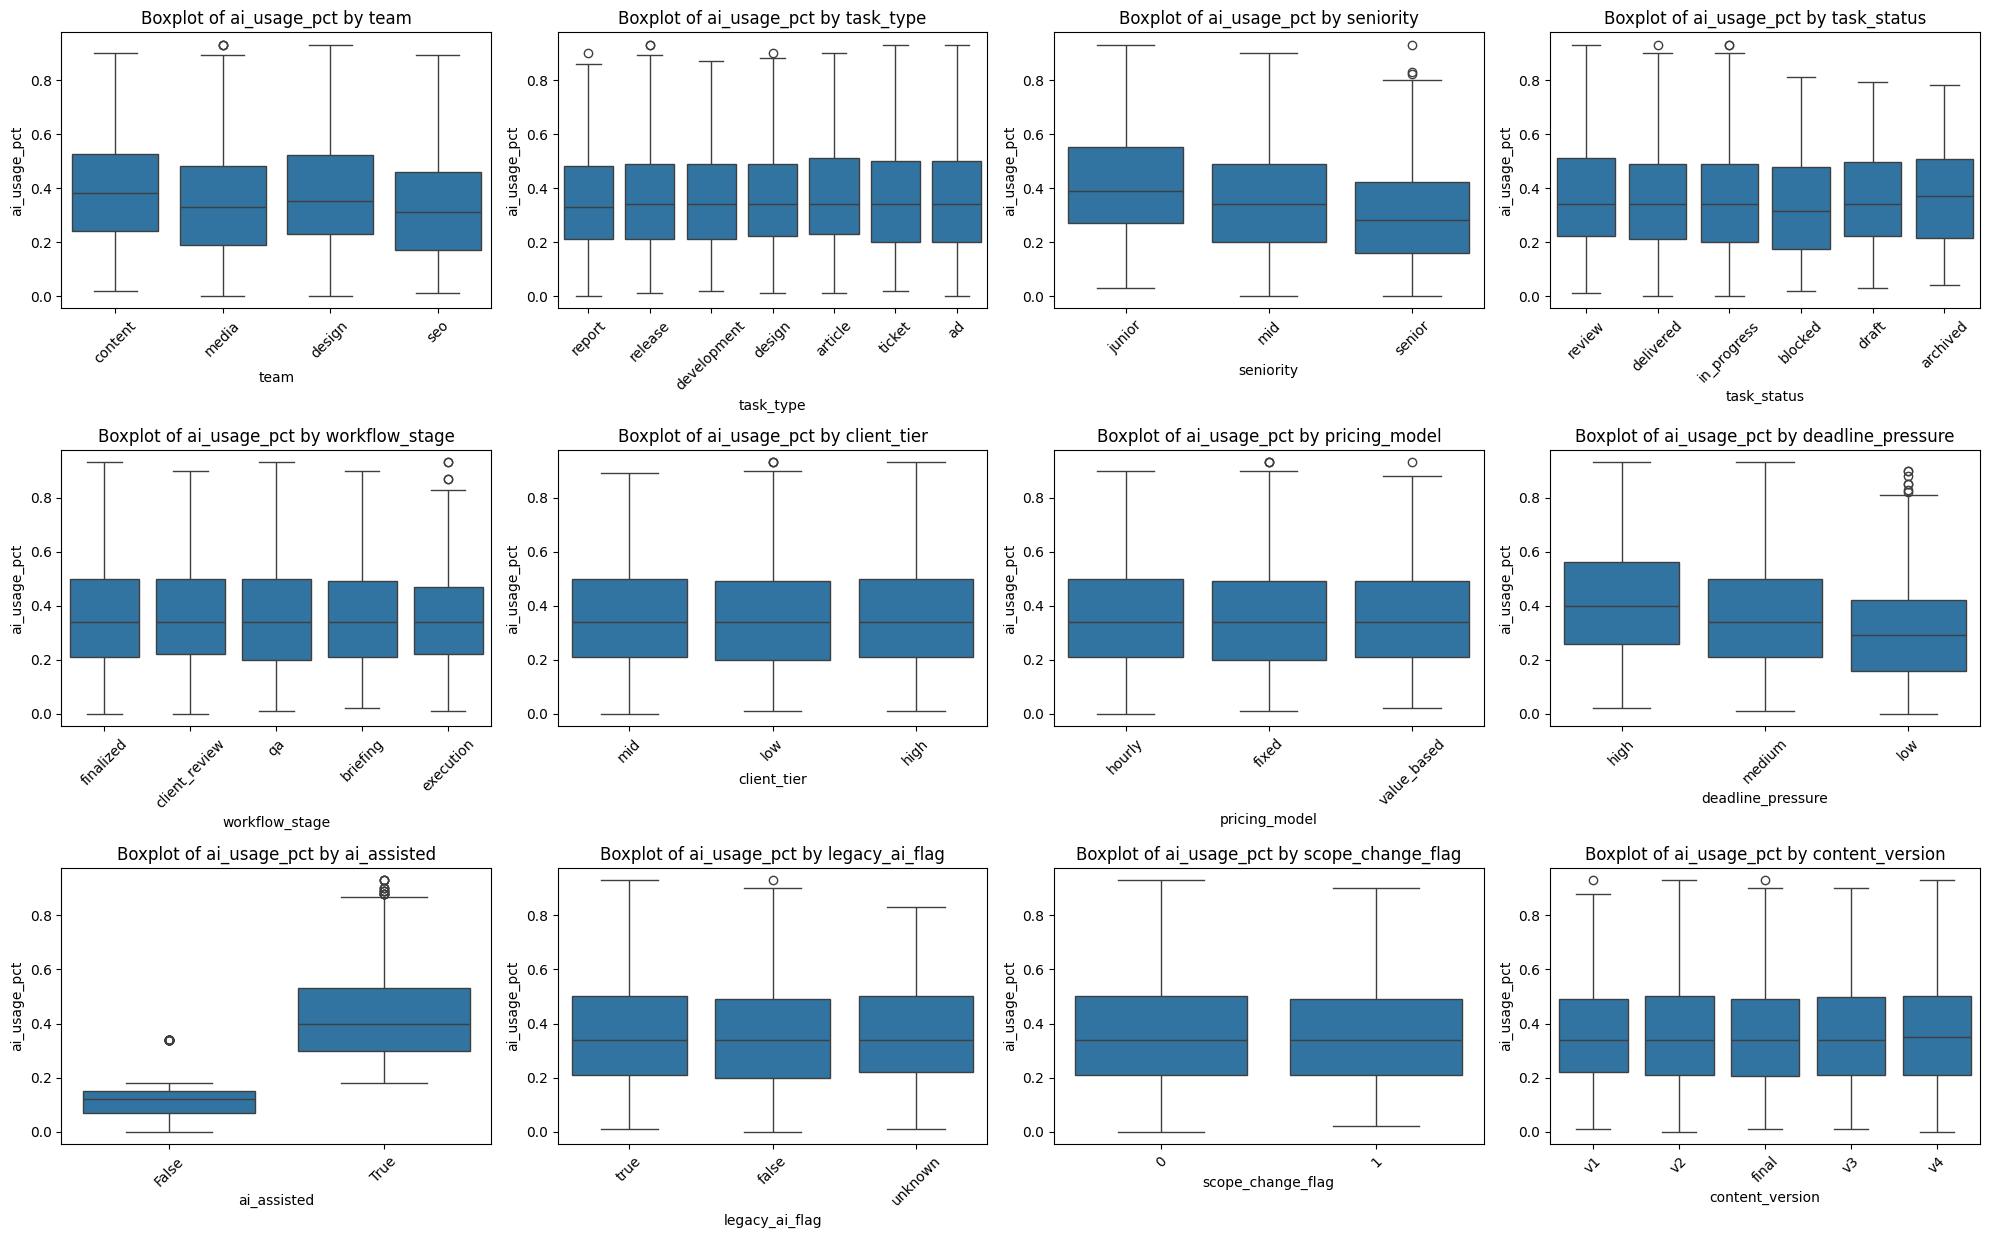

In [57]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["ai_usage_pct"])
    plt.title(f"Boxplot of ai_usage_pct by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Boxplot for categorical variables on `outcome_score`

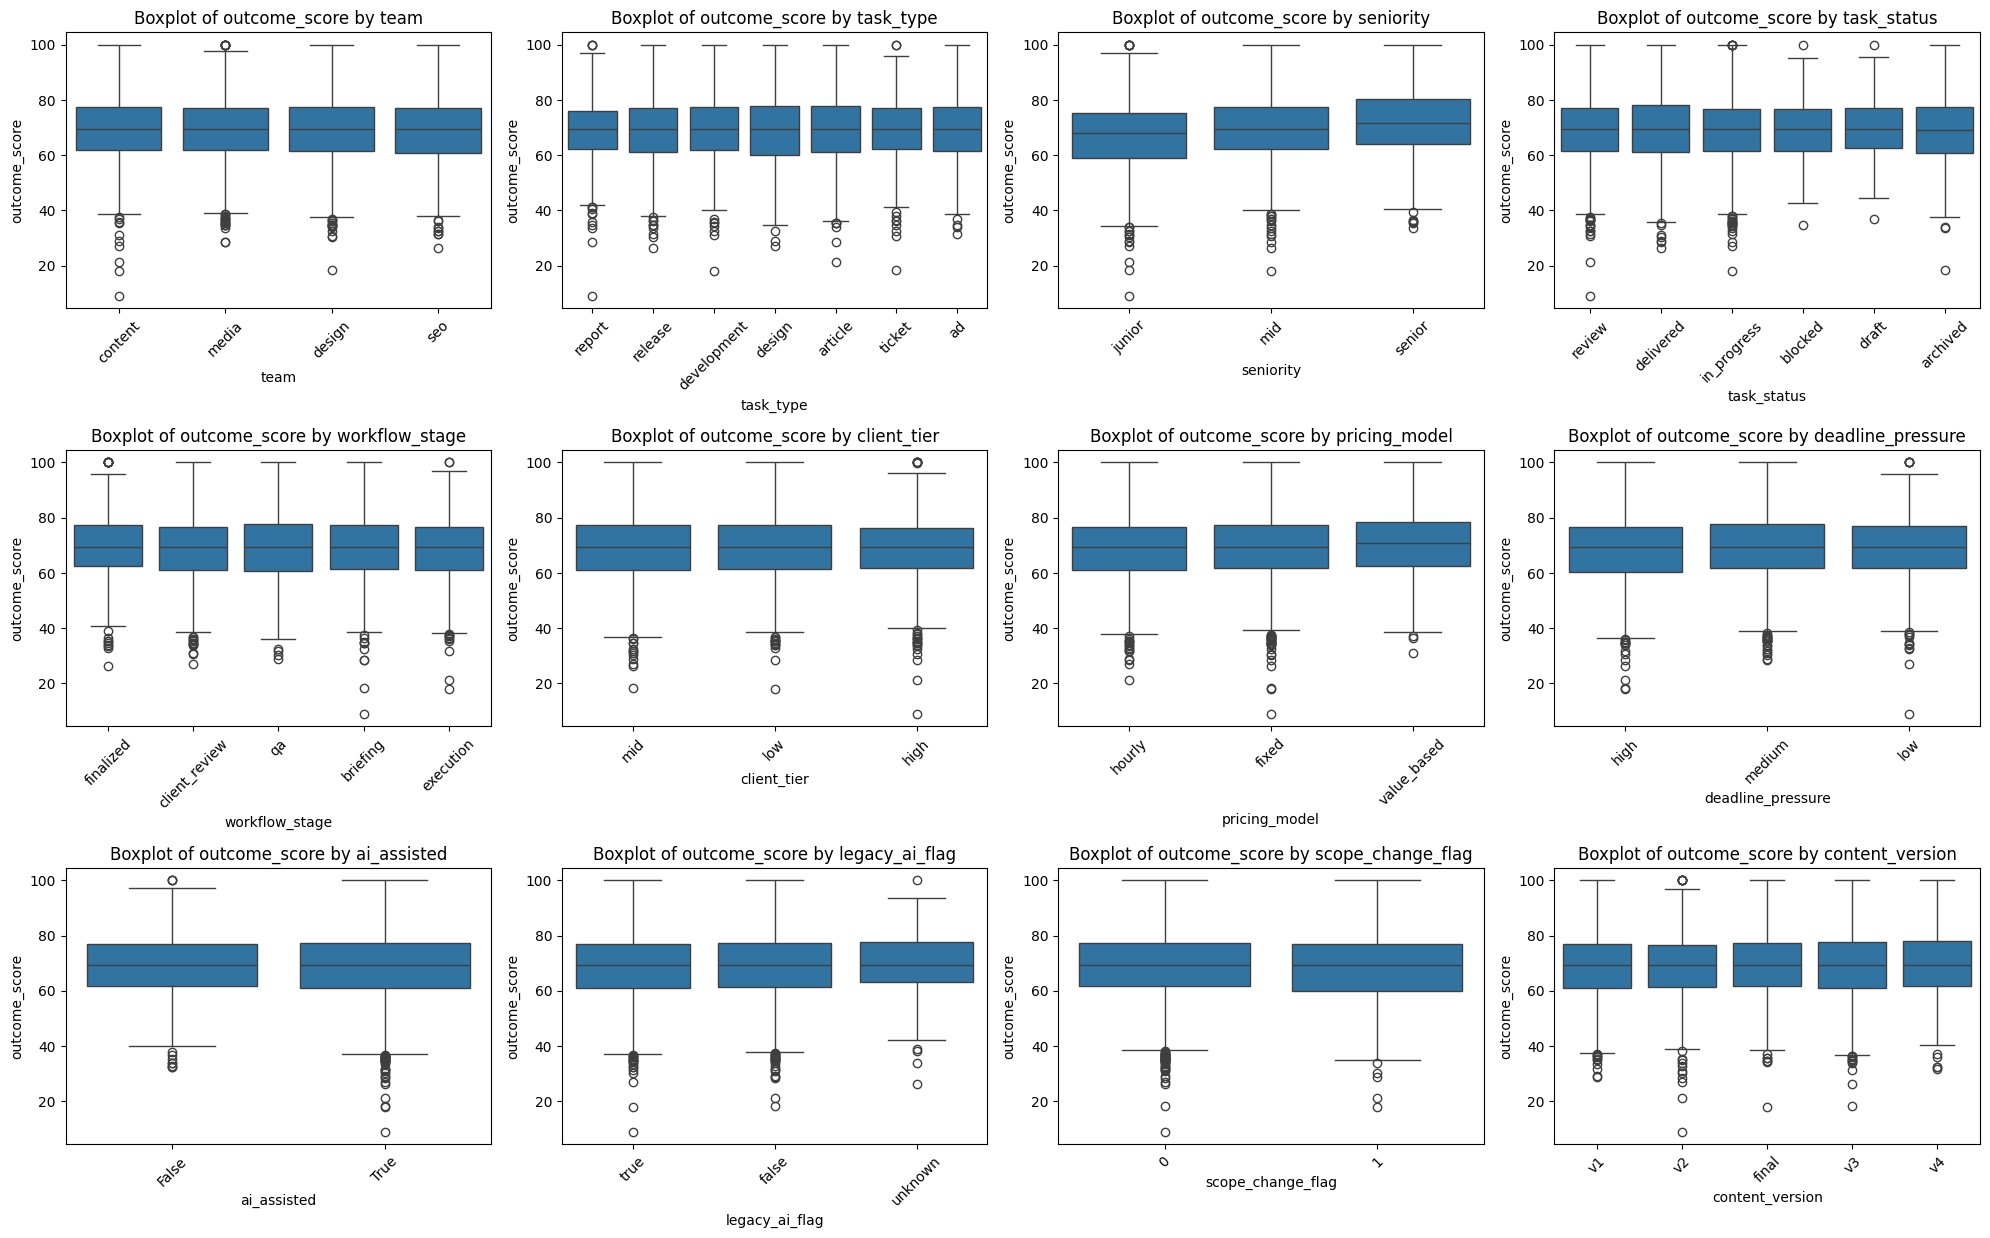

In [58]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["outcome_score"])
    plt.title(f"Boxplot of outcome_score by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Feature Engineering

We create derived variables that directly address the research questions around margin impact, quality, speed, and AI usage intensity.

### 7.1 INCONSISTENCIES

#### 7.1.1 Checking inconsistencies in `hours_spent`, `rework_hours` and `billable_hours`

In [59]:
negative_hours_spent = final_df[final_df['hours_spent'] < 0]
negative_billable_hours = final_df[final_df['billable_hours'] < 0]
negative_rework_hours = final_df[final_df['rework_hours'] < 0]

print("Negative hours_spent:", len(negative_hours_spent))
print("Negative billable_hours:", len(negative_billable_hours))
print("Negative rework_hours:", len(negative_rework_hours))

# We set to median the negative values for billable_hours and check if everything went well
final_df.loc[final_df['billable_hours'] < 0, 'billable_hours'] = final_df['billable_hours'].median()
print("Negative billable_hours after updating:", len(final_df[final_df['billable_hours'] < 0]))

Negative hours_spent: 0
Negative billable_hours: 17
Negative rework_hours: 0
Negative billable_hours after updating: 0


#### 7.1.2 `task_complexity_score` and `brief_quality_score`

In [60]:
# check if there are negative values for task_complexity_score, brief_quality_score
negative_task_complexity_score = final_df[final_df['task_complexity_score'] < 0]
negative_brief_quality_score = final_df[final_df['brief_quality_score'] < 0]

print("Negative task_complexity_score:", len(negative_task_complexity_score))
print("Negative brief_quality_score:", len(negative_brief_quality_score))

Negative task_complexity_score: 0
Negative brief_quality_score: 0


#### 7.1.3 `created_at`, `updated_at` and `delivered_at`
I first check for inconsistencies between `created_at`, `updated_at`, and `delivered_at`.

A small number of cases (14) show `created_at` later than `delivered_at`, which is not logically consistent. Since these cases are very few, I assume they are due to swapped dates and correct them by switching the two columns.

On the other hand, many cases show `updated_at` later than `delivered_at`. This is expected, since `updated_at` represents the last modification of the record and can occur after delivery (e.g. for administrative updates or corrections). For this reason, no correction is applied in this case.

After fixing the inconsistencies, I compute the `delivery_time` as the difference (in days) between `delivered_at` and `created_at`.

The resulting values are all non-negative and fall within a reasonable range, confirming that the date variables are now consistent.

In [61]:
final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days
(final_df['delivered_at'] < final_df['created_at']).sum()
(final_df['delivered_at'] < final_df['updated_at']).sum()
col_to_see = ["task_id", "created_at", "delivered_at", "project_id", "team"]

final_df[final_df["delivered_at"] < final_df["created_at"]][col_to_see]

,task_id,created_at,delivered_at,project_id,team
89,T00089,2025-10-06,2025-10-05,P052,media
403,T00403,2026-02-09,2026-02-08,P035,seo
878,T00878,2026-03-29,2026-03-26,P035,seo
1083,T01083,2025-11-13,2025-11-12,P024,media
1112,T01112,2025-12-06,2025-12-05,P055,design
1163,T01163,2026-05-03,2026-04-30,P003,content
1169,T01169,2026-01-21,2026-01-20,P045,design
1230,T01230,2026-04-20,2026-04-17,P013,content
2127,T02127,2026-05-01,2026-04-30,P054,content
2131,T02131,2025-10-19,2025-10-16,P033,content


In [62]:
# identify rows with swapped dates and swap them back  
neg_mask = final_df["created_at"] > final_df["delivered_at"]
print("Number of rows with created_at > delivered_at:", neg_mask.sum())  

# Correcting the swapped dates in the created_at and delivered_at columns
final_df.loc[neg_mask, ["created_at", "delivered_at"]] = final_df.loc[neg_mask, ["delivered_at", "created_at"]].values

# checking if updated_at > delivered_at
neg_mask2 = final_df["updated_at"] > final_df["delivered_at"]
print("Number of rows with updated_at > delivered_at:", neg_mask2.sum())

# checking if created_at > updated_at
neg_mask3 = final_df["created_at"] > final_df["updated_at"]
print("Number of rows with created_at > updated_at:", neg_mask3.sum())

# we now check if everything went well. We expect to have values different from 0 only in the neg_mask2 (updated_at > delivered_at)
neg_mask = final_df["created_at"] > final_df["delivered_at"]
neg_mask2 = final_df["updated_at"] > final_df["delivered_at"]
neg_mask3 = final_df["created_at"] > final_df["updated_at"]
print("Number of rows with created_at > delivered_at after updating:", neg_mask.sum())  
print("Number of rows with updated_at > delivered_at: after updating", neg_mask2.sum())
print("Number of rows with created_at > updated_at: after updating", neg_mask3.sum())

final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days
final_df["delivery_time"].describe()

Number of rows with created_at > delivered_at: 14
Number of rows with updated_at > delivered_at: 1440
Number of rows with created_at > updated_at: 0
Number of rows with created_at > delivered_at after updating: 0
Number of rows with updated_at > delivered_at: after updating 1440
Number of rows with created_at > updated_at: after updating 0


count    3198.000000
mean        4.495310
std         1.766776
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: delivery_time, dtype: float64

Handling 38 nan values previously spotted adding the mean between `delivered_at` - `created_at`. We also update the `delivery_time`, previously computed.


In [63]:
final_df['delivered_at'] = final_df['delivered_at'].fillna(final_df['created_at'] + (final_df['delivered_at'] - final_df['created_at']).mean())
final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days

missing_values = final_df.isnull().sum()
print(missing_values[missing_values > 0])

jira_ticket    339
dtype: int64


#### 7.1.4 `sla_breach` vs `delivery_time`
We want to understand if zero correspond to tasks that were delivered in time or not

In [64]:
final_df["sla_breach_check"] = (final_df["delivery_time"] > final_df["sla_days"]).astype(int)
final_df[final_df["sla_breach"] != final_df["sla_breach_check"]][["task_id", "delivery_time", "sla_days", "sla_breach", "sla_breach_check"]].tail(20)   

,task_id,delivery_time,sla_days,sla_breach,sla_breach_check
895,T00895,5,5.0,1,0
939,T00939,5,5.0,1,0
1112,T01112,1,3.0,1,0
1684,T01684,4,5.0,1,0
1928,T01928,5,5.0,1,0
1944,T01944,5,5.0,1,0
2127,T02127,1,5.0,1,0
2131,T02131,3,5.0,1,0
2136,T02136,4,3.0,0,1
2184,T02184,4,5.0,1,0


In [65]:
# with this espression: final_df["sla_breach_check"] = (final_df["delivery_time"] > final_df["sla_days"]).astype(int) 
# we have assigned zero if delivery_time was less or equal than sla_days (it's on time) 
# and 1 if delivery_time was greater than sla_days (it's late)

inconsistencies = (final_df["sla_breach"] != final_df["sla_breach_check"]).sum()
total = len(final_df)

print(f"Inconsistencies: {inconsistencies} on {total} ({inconsistencies/total*100:.1f}%)")
print("Distribution:")
print(final_df.groupby(["sla_breach", "sla_breach_check"]).size().reset_index(name="count"))

Inconsistencies: 26 on 3236 (0.8%)
Distribution:
   sla_breach  sla_breach_check  count
0           0                 0   1945
1           0                 1      4
2           1                 0     22
3           1                 1   1265


A consistency check between the original `sla_breach` variable and a recomputed version based on `delivery_time` > `sla_days` revealed about 1% inconsistencies, meaning the original variable cannot be considered reliable.
Our decision: `sla_breach` has been fully replaced with the recomputed version, where:
- 1 = `delivery_time` > `sla_days`  (task delivered late — breach)
- 0 = `delivery_time` <= `sla_days` (task delivered on time — no breach)


In [66]:
final_df["sla_breach"] = final_df["sla_breach_check"]
final_df.drop(columns=["sla_breach_check"], inplace=True)

## 7.2 Handling columns that contain AI in the name 

In [67]:
#filter columns with ai in the name
ai_cols = [col for col in final_df.columns if "ai" in col]
print(ai_cols)

['ai_usage_pct', 'ai_assisted', 'legacy_ai_flag']


#### 7.2.1 AI_group
We create bins on `ai_usage_pct` calling them `ai_group`. The first divisions was  0-25% / 25-50% / 50-75% / 75-100% but after plotting we see that the second bin was highly concentrated so we decided to divide a little bit more the bins. The new ones are 0-15% / 15-30% / 30-50% / 50-75% / 75-100%

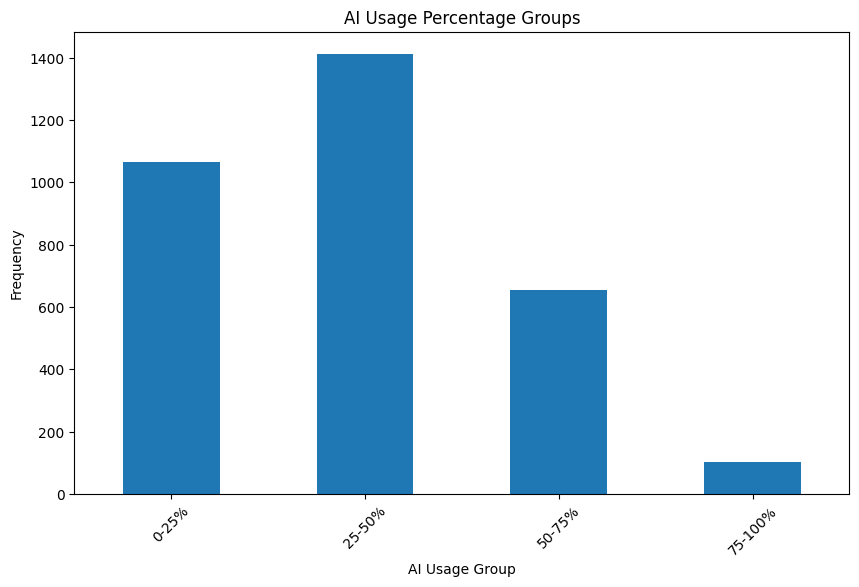

In [68]:
final_df["ai_group"] = pd.cut(final_df["ai_usage_pct"], bins=[-1, 0.25, 0.5, 0.75, 1], labels=["0-25%", "25-50%", "50-75%", "75-100%"])
final_df["ai_group"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
final_df["ai_group"].value_counts().sort_index().plot(kind="bar")
plt.title("AI Usage Percentage Groups")
plt.xlabel("AI Usage Group")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

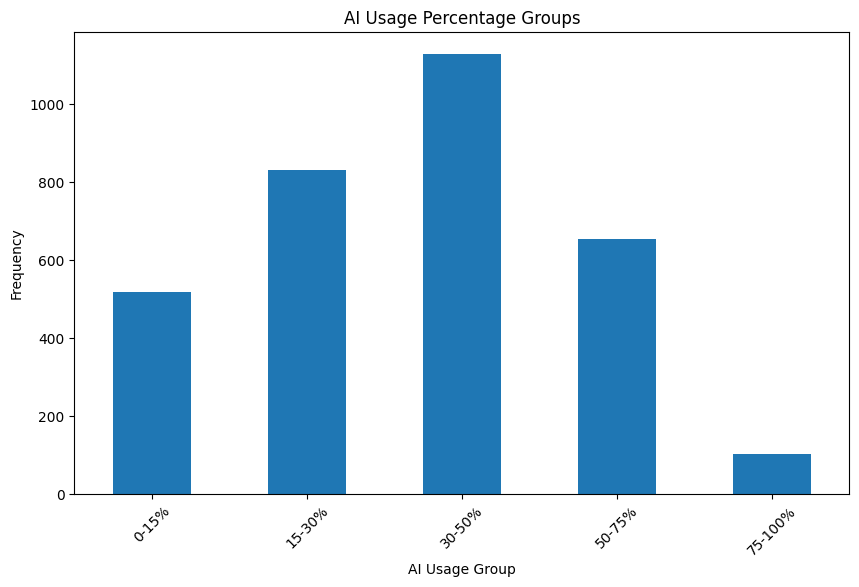

In [69]:
final_df["ai_group"] = pd.cut(final_df["ai_usage_pct"], bins=[-1, 0.15, 0.3, 0.5, 0.75, 1], labels=["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"])
final_df["ai_group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
final_df["ai_group"].value_counts().sort_index().plot(kind="bar")
plt.title("AI Usage Percentage Groups")
plt.xlabel("AI Usage Group")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

#### 7.2.2 `ai_assisted = False` but `ai_usage_pct > 0`


685 rows have `ai_assisted` = False despite a positive `ai_usage_pct`.
We found that 517 cases fall within the 0–15% usage bucket, suggesting low-level AI involvement that was not formally flagged as assisted.
An additional 136 cases fall within the 15–30% range, indicating that most inconsistencies are still concentrated at relatively low levels of AI usage. Only 30 cases exceed 30%, and none are observed above 50%.


**Resolution strategy:** we compute the median `ai_usage_pct` among these inconsistent rows and use it as a threshold. Tasks above the threshold are reclassified as `ai_assisted = True`; tasks at or below it are treated as genuinely non-assisted and their `ai_usage_pct` is set to 0.

In [70]:
# inspect ai_usage_pct distribution for inconsistent rows (ai_assisted=False but ai_usage_pct > 0)  
# gestire il problema ai usage / ai assisted
inconsistent_mask = (final_df["ai_assisted"] == False) & (final_df["ai_usage_pct"] > 0)  
print("Inconsistent rows:", inconsistent_mask.sum())  
print()  
print(final_df[inconsistent_mask]["ai_usage_pct"].describe())  
print()  
print("Distribution across ai_group:")  
print(final_df[inconsistent_mask]["ai_group"].value_counts())

Inconsistent rows: 683

count    683.000000
mean       0.118638
std        0.065176
min        0.010000
25%        0.070000
50%        0.120000
75%        0.150000
max        0.340000
Name: ai_usage_pct, dtype: float64

Distribution across ai_group:
ai_group
0-15%      517
15-30%     136
30-50%      30
50-75%       0
75-100%      0
Name: count, dtype: int64


In [71]:
 # we use the median of ai_usage_pct among these rows as the threshold  

threshold = final_df[inconsistent_mask]["ai_usage_pct"].median()  
print(f"Threshold: {threshold:.3f}")  

# rows above threshold: reclassify as ai_assisted = True  
above_threshold = inconsistent_mask & (final_df["ai_usage_pct"] > threshold)  
final_df.loc[above_threshold, "ai_assisted"] = True  

# rows at or below threshold: set ai_usage_pct = 0 (treat as non-assisted)  
below_threshold = inconsistent_mask & (final_df["ai_usage_pct"] <= threshold)  
final_df.loc[below_threshold, "ai_usage_pct"] = 0  

# verify: no inconsistent rows should remain  
remaining = (final_df["ai_assisted"] == False) & (final_df["ai_usage_pct"] > 0)  
print(f"Remaining inconsistencies: {remaining.sum()}")  
print()  
print("Updated ai_assisted distribution:")  
print(final_df["ai_assisted"].value_counts())  

Threshold: 0.120
Remaining inconsistencies: 0

Updated ai_assisted distribution:
ai_assisted
True     2854
False     382
Name: count, dtype: int64


#### 7.2.3 AI Complexity Interaction

Task complexity is measured on a discrete scale from 1 to 5. This new column is a proxy to see whether the effectiveness of AI varies across different levels of complexity.

In [72]:
final_df["ai_complexity"] = final_df["task_complexity_score"] * final_df["ai_usage_pct"]

## 7.3 METRICS

#### 7.3.1 Cost Metrics
`rework_ratio`: share of total hours spent on corrections, higher values indicate more waste.

`cost_ratio`: how much of each euro of revenue is absorbed by costs.

`efficiency`: how much time spent on a task is actually billable to the client (consider that rework_hours are not paid)

If efficiency:

"= 1" all worked hours are billable

"> 1" More hours are billed than actually spent. This is generally a positive outcome and may reflect high productivity.

"< 1" Fewer hours are billed than worked. This indicates inefficiency, as some time is not generating revenue

In [73]:
final_df["rework_ratio"] = final_df["rework_hours"] / (final_df["hours_spent"] + final_df["rework_hours"])
final_df["cost_ratio"] = final_df["cost"] / final_df["revenue"]
final_df["efficiency"] = final_df["billable_hours"] / final_df["hours_spent"]

#### 7.3.2  Error and Revision Metrics 
We built `error_rate` and `revisions_rate`on `hours_spent`

In [74]:
final_df["error_rate"] = final_df["errors"] / final_df["hours_spent"]
final_df["revisions_rate"] = final_df["revisions"] / final_df["hours_spent"]

#### 7.3.3  Margin and  Profitability Metrics

These features directly address the reaserch question 1 (margin impact of AI) and reaserch question 5 (threshold detection) which we will answer later.  

`profit_margin` captures how much of the revenue generated is actually retained by the company. 

`is_loss` is a binary flag to isolate tasks where the firm lost money.

In [75]:
final_df["profit_margin"] = (final_df["profit"] / final_df["revenue"])
final_df["profit_per_hour"] = final_df["profit"] / final_df["hours_spent"]

Binary flag: did this task generate a loss?  

In [76]:
final_df["is_loss"] = (final_df["profit"] < 0).astype(int)  
final_df[["profit", "profit_margin", "profit_per_hour", "is_loss"]].describe()  

,profit,profit_margin,profit_per_hour,is_loss
count,3236.000000,3236.000000,3236.000000,3236.000000
mean,350.019566,0.149083,100.182603,0.250618
std,889.433950,0.765239,2223.595969,0.433436
min,-8510.549511,-16.736802,-26539.473176,0.000000
25%,-2.040000,-0.002346,-0.172395,0.000000
50%,255.825000,0.290878,23.469384,0.000000
75%,590.770000,0.513120,53.302155,1.000000
max,14006.644324,0.962587,102291.000000,1.000000


## 8. Drop Identifier Columns 

Columns that are pure identifiers or metadata (`task_id`, `jira_ticket`, `created_by`, `project_id`, `missing_flag`) carry no analytical or predictive value. We drop them from `final_df`

In [77]:
# drop identifier and metadata columns  
cols_to_drop = ["task_id", "jira_ticket", "created_by", "project_id", "missing_flag"]  
final_df = final_df.drop(columns=cols_to_drop, errors="ignore")  

print("final_df shape:", final_df.shape)  
print()  
print("Columns in final_df:")  
print(final_df.dtypes)  

final_df shape: (3236, 41)

Columns in final_df:
client                              str
client_tier                         str
team                                str
task_type                           str
seniority                           str
task_complexity_score             int64
brief_quality_score             float64
deadline_pressure                   str
scope_change_flag                 int64
pricing_model                       str
created_at               datetime64[us]
delivered_at             datetime64[us]
sla_days                        float64
sla_breach                        int64
hours_spent                     float64
billable_hours                  float64
ai_usage_pct                    float64
ai_assisted                        bool
revisions                         int64
errors                            int64
rework_hours                    float64
outcome_score                   float64
revenue                         float64
cost                           

# 9. Answers to the questions posed 

## RQ1 - Where is value created?

#### T-test for value creation

To compare AI-assisted and non-assisted tasks we use a two sample t-test, which tests whether
the difference in group means is likely due to chance or reflects a real underlying pattern.
We report results at three significance levels (10%, 5%, 1%) to give a more complete picture
rather than a binary yes/no.

Looking at financial performance, AI-assisted tasks show a higher average profit margin (0.16 vs 0.08)
and lower cost ratio (0.84 vs 0.92), both significant at the 10% level. Revenue and profit per hour
point in the same direction but don't reach statistical significance, suggesting the financial benefit
of AI is real but still emerging, likely concentrated in specific task types or teams rather than
uniform across the board.

In [78]:
ai_on  = final_df[final_df["ai_assisted"] == True]
ai_off = final_df[final_df["ai_assisted"] == False]

value_metrics = [("profit_margin",  "Profit Margin"),
    ("profit_per_hour","Profit per Hour"),
    ("cost_ratio",     "Cost Ratio"),
    ("efficiency",     "Efficiency"),
    ("revenue",        "Revenue")]

for metric, label in value_metrics:
    m_on  = ai_on[metric].mean()
    m_off = ai_off[metric].mean()
    t_stat, p_val = stats.ttest_ind(ai_on[metric].dropna(), ai_off[metric].dropna())
    print(f"{label}")
    print(f"  AI assisted: {m_on:.2f}  |  No AI: {m_off:.2f}")
    print(f"  t-test p={p_val:.4f}")
    print(f"    α=0.10 -> {'Significant' if p_val < 0.10 else 'Not significant'}")
    print(f"    α=0.05 -> {'Significant' if p_val < 0.05 else 'Not significant'}")
    print(f"    α=0.01 -> {'Significant' if p_val < 0.01 else 'Not significant'}\n")

Profit Margin
  AI assisted: 0.16  |  No AI: 0.08
  t-test p=0.0698
    α=0.10 -> Significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant

Profit per Hour
  AI assisted: 110.06  |  No AI: 26.37
  t-test p=0.4897
    α=0.10 -> Not significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant

Cost Ratio
  AI assisted: 0.84  |  No AI: 0.92
  t-test p=0.0698
    α=0.10 -> Significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant

Efficiency
  AI assisted: 1.35  |  No AI: 0.87
  t-test p=0.4452
    α=0.10 -> Not significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant

Revenue
  AI assisted: 1128.01  |  No AI: 1070.94
  t-test p=0.2139
    α=0.10 -> Not significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant



### Scatter ai_usage_pct vs Profit Margin and Outcome Score

The scatter plots show no clear relationship, the regression lines are nearly 
flat and the points are too dispersed to draw conclusions.

We will therefore analyze AI impact using the `ai_group` buckets defined 
earlier, which make the patterns more readable.

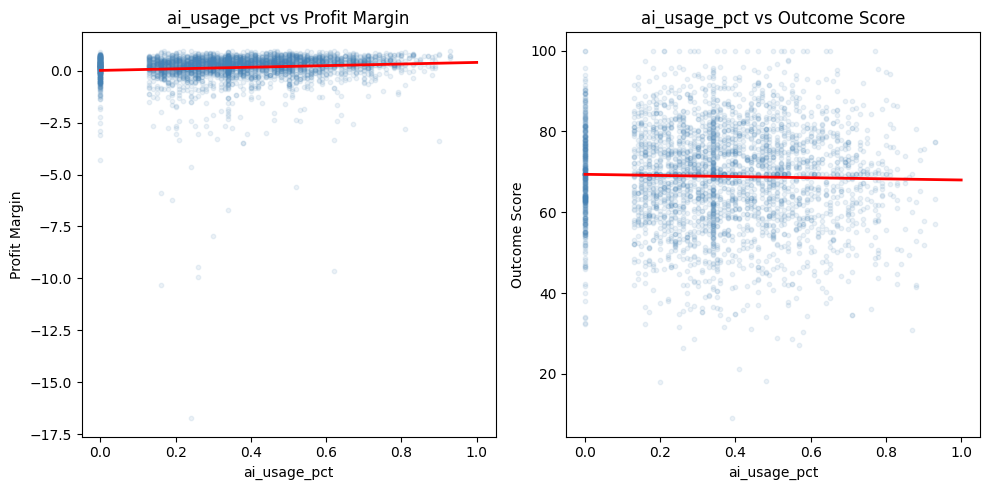

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, metric, label in zip(axes,
                              ["profit_margin", "outcome_score"],
                              ["Profit Margin", "Outcome Score"]):
    ax.scatter(final_df["ai_usage_pct"], final_df[metric], alpha=0.1, s=10, color="steelblue")
    m, b = np.polyfit(final_df["ai_usage_pct"].dropna(), final_df[metric].dropna(), 1)
    x = np.linspace(0, 1, 100)
    ax.plot(x, m*x + b, color="red", linewidth=2)
    ax.set_xlabel("ai_usage_pct")
    ax.set_ylabel(label)
    ax.set_title(f"ai_usage_pct vs {label}")

plt.tight_layout()
plt.show()

### Profitability for AI group

`profit_margin` increases nearly monotonically with AI usage intensity.

The chart shows a clear positive trend: the more AI is used, the higher the average `profit_margin`. Groups using AI more than 50% of the time achieve margins above 23%, peaking at 34% for the 75-100% group. 

The only anomaly is the 15-30% bucket, which drops below the 0-15% group, likely due to a transition phase where AI is used enough to add overhead but not enough to generate real efficiency gains.

/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/2656863113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=final_df,


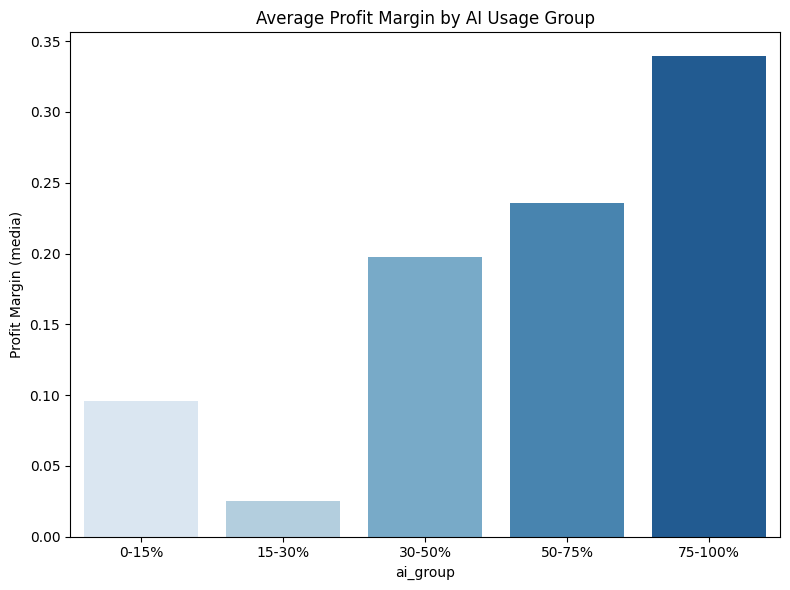

In [80]:
plt.figure(figsize=(8, 6))
order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

sns.barplot( data=final_df,
    x="ai_group",
    y="profit_margin",
    order=order,
    palette="Blues",
    errorbar=None)

plt.title("Average Profit Margin by AI Usage Group")
plt.ylabel("Profit Margin (media)")
plt.tight_layout()
plt.show()

Loss rate drops from ~30% in low-usage groups to 11.6% at high usage, suggesting that intensive AI adoption reduces both average costs 
and downside risk.

The 15–30% group is the most dangerous: its mean collapses to 0.025 probebly due to extreme negative outliers. 
This "partial adoption" scenario, where AI is introduced but not fully integrated and is the worst in terms of `margin_profit`.

In [81]:
#profit_per_hour for ai_group. 
summary = final_df.groupby("ai_group", observed=True).agg(
    mean_profit_margin=("profit_margin", "mean"),
    mean_profit_per_hour=("profit_per_hour", "mean"),
    n=("profit_margin", "count")
).reset_index()
print(summary)

  ai_group  mean_profit_margin  mean_profit_per_hour     n
0    0-15%            0.095646             53.169385   519
1   15-30%            0.025373             41.912193   832
2   30-50%            0.197317            190.995663  1128
3   50-75%            0.235722             59.092054   654
4  75-100%            0.339304             74.133380   103


### Estimate of cost of `rework_hours`
We estimate of rework_hours cost with three scenarios:
- pessimistic where `hourly_cost` of `rework_hours` are more expensive than the traditional ones
- optimistic where `hourly_cost` of `rework_hours` are less expensive than the traditional ones
- normal where `hourly_cost` of `rework_hours` are expensive as the traditional ones

In [82]:
final_df["hourly_cost"] = (final_df["cost"] / final_df["hours_spent"])

# scenarios
final_df["hourly_cost_optimistic"] = final_df["hourly_cost"] * 0.5
final_df["hourly_cost_normal"] = final_df["hourly_cost"] * 1.0
final_df["hourly_cost_pessimistic"] = final_df["hourly_cost"] * 1.5

# rework cost estimates
final_df["rework_cost_optimistic"] = final_df["hourly_cost_optimistic"] * final_df["rework_hours"]
final_df["rework_cost_normal"] = final_df["hourly_cost_normal"] * final_df["rework_hours"]
final_df["rework_cost_pessimistic"] = final_df["hourly_cost_pessimistic"] * final_df["rework_hours"]

# we create another metric to track the estimation made for rework_hours, accounting the different scenario
final_df["cost_ratio_optimistic"] = (final_df["cost"] + final_df["rework_cost_optimistic"]) / final_df["revenue"]

final_df["cost_ratio_normal"] = (final_df["cost"] + final_df["rework_cost_normal"]) / final_df["revenue"]

final_df["cost_ratio_pessimistic"] = (final_df["cost"] + final_df["rework_cost_pessimistic"]) / final_df["revenue"]


In [83]:
# profit per scenario
final_df["profit_optimistic"]  = final_df["revenue"] - (final_df["cost"] + final_df["rework_cost_optimistic"])
final_df["profit_normal"]      = final_df["revenue"] - (final_df["cost"] + final_df["rework_cost_normal"])
final_df["profit_pessimistic"] = final_df["revenue"] - (final_df["cost"] + final_df["rework_cost_pessimistic"])

# profit margin per scenario 
final_df["profit_margin_optimistic"]  = final_df["profit_optimistic"]  / final_df["revenue"]
final_df["profit_margin_normal"]      = final_df["profit_normal"]      / final_df["revenue"]
final_df["profit_margin_pessimistic"] = final_df["profit_pessimistic"] / final_df["revenue"]

The 75-100% AI group is the only one maintaining positive or near-zero margins across all three scenarios, confirming high AI adoption as a profitability buffer.

The 50-75% group suffers the worst losses, reaching ≈ -85% in the Pessimistic scenario, reflecting extreme sensitivity to rework cost assumptions.

Across all groups, profitability deteriorates sharply from Optimistic to Pessimistic, highlighting how rework costs are the key driver of financial risk.


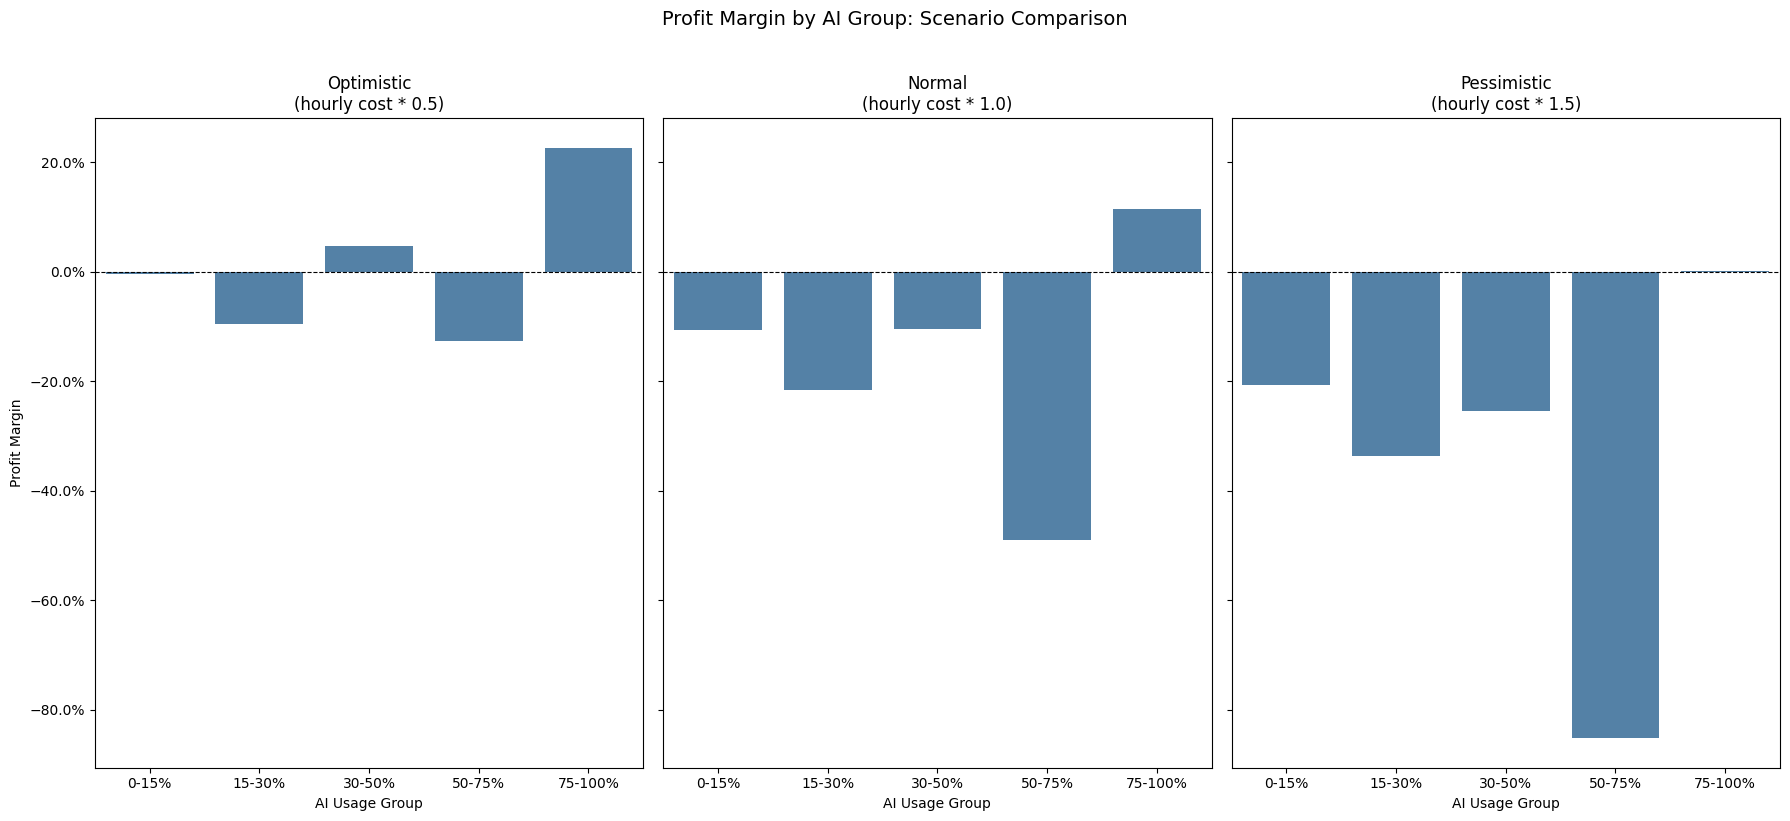

In [84]:
scenarios = [
    ("profit_margin_optimistic",  "Optimistic",  "hourly cost * 0.5"),
    ("profit_margin_normal",      "Normal",      "hourly cost * 1.0"),
    ("profit_margin_pessimistic", "Pessimistic", "hourly cost * 1.5"),
]

order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

for ax, (col, title, subtitle) in zip(axes, scenarios):
    sns.barplot(
        data=final_df,
        x="ai_group",
        y=col,
        order=order,
        errorbar=None,
        color="steelblue",
        ax=ax,
    )
    ax.set_title(f"{title}\n({subtitle})", fontsize=12)
    ax.set_xlabel("AI Usage Group")
    ax.set_ylabel("Profit Margin" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.tick_params(axis="x", rotation=0)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")  
    
# we add a zero-line utile per il margin

fig.suptitle("Profit Margin by AI Group: Scenario Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Where does AI create the most value? By task type and team

By `task type`: AI boosts margins consistently in structured tasks like **design,report** and **tickets** the more you use it, the better. The exception is **articles**: pushing AI usage to the maximum actually turns margins negative, suggesting that creative, writing-heavy work still needs a human hand. Over-automating where judgment matters costs more than it saves.

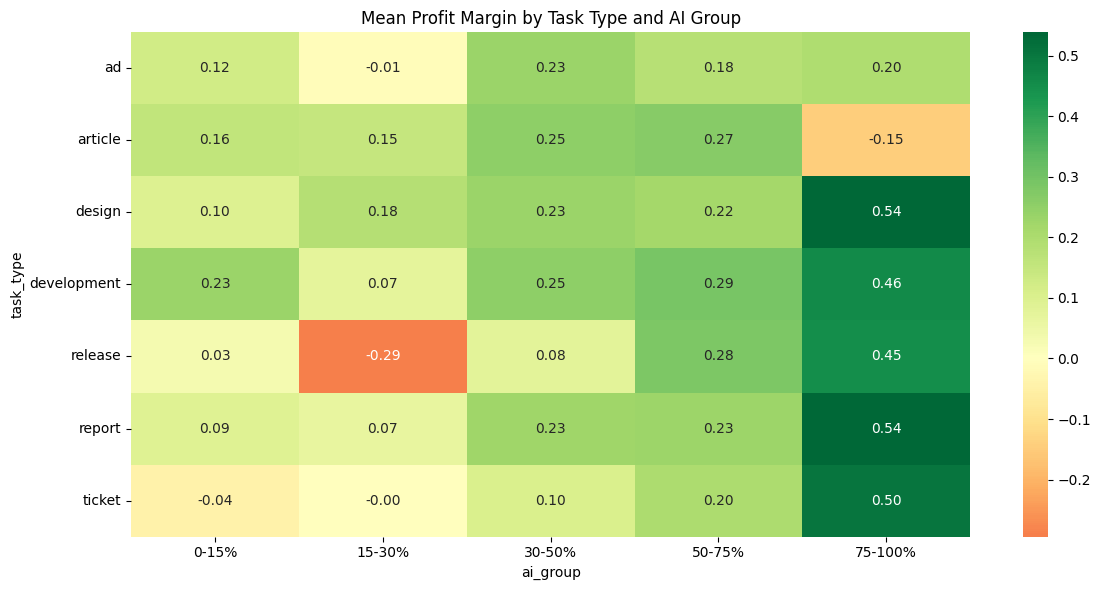

In [85]:
pivot = final_df.groupby(["task_type", "ai_group"], observed=True)["profit_margin"].mean().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Mean Profit Margin by Task Type and AI Group")
plt.tight_layout()
plt.show()

By `team`: Every team ends up better with high AI usage, but the path isn't always smooth: design and SEO both dip early before recovering, the classic sign of a learning curve. Media has the most dramatic turnaround, starting near zero and hitting 0.36. No team gets hurt by going all-in.

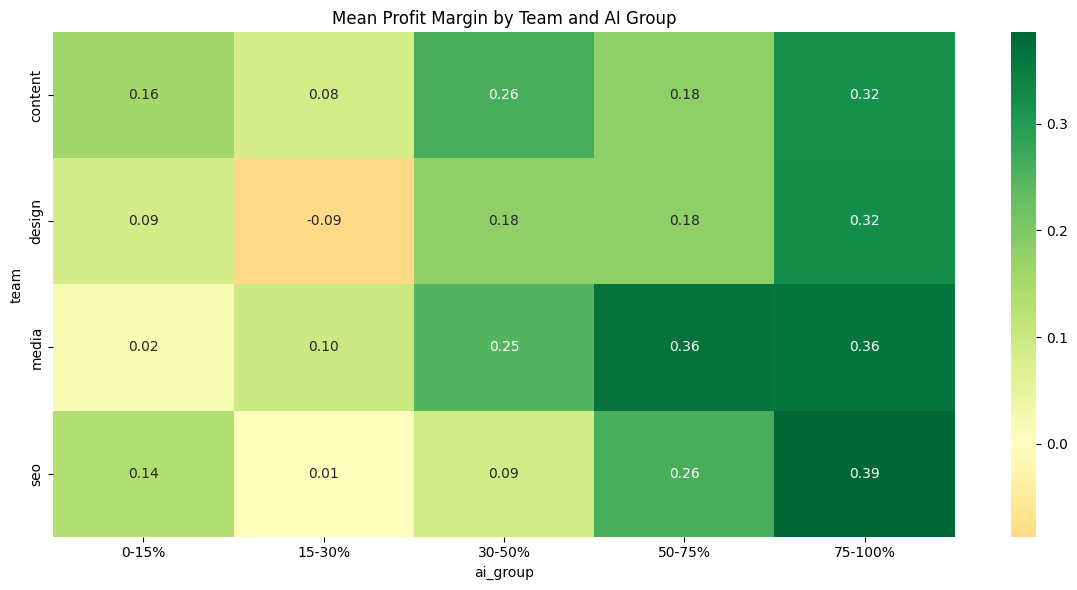

In [86]:
# the same for team
pivot_team = final_df.groupby(["team", "ai_group"], observed=True)["profit_margin"].mean().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_team, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Mean Profit Margin by Team and AI Group")
plt.tight_layout()
plt.show()

## RQ2 - Where are losses incurred ? 

#### T-test for losses

Using the same two-sample t-test approach for quality metrics. We compare quality and delivery metrics between
AI-assisted and non-assisted tasks. The t-test is appropriate here since we are comparing
continuous metrics across two independent groups, with no assumption that one caused the other.

The quality picture is more nuanced. Rework hours and rework ratio are both highly significant
(p < 0.01), but in the unexpected direction, AI-assisted tasks accumulate more rework, not less.
Revisions follow a similar pattern, significant at 10%. Errors, error rate, and outcome score show
no meaningful difference between the two groups. This suggests AI may speed up delivery but
introduce more back-and-forth in the process, which is worth monitoring closely.

In [87]:
metrics = [
    ("revisions",     "Revisions"),
    ("errors",        "Errors"),
    ("rework_hours",  "Rework Hours"),
    ("rework_ratio",  "Rework Ratio"),
    ("error_rate",    "Error Rate")]

print("LOSSES ANALYSIS — Where Does AI Help?\n")

for metric, label in metrics:
    m_on  = ai_on[metric].mean()
    m_off = ai_off[metric].mean()
    t_stat, p_val = stats.ttest_ind(ai_on[metric].dropna(), ai_off[metric].dropna())
    print(f"{label}")
    print(f"  AI assisted: {m_on:.2f}  |  No AI: {m_off:.2f}")
    print(f"  t-test p={p_val:.4f}")
    print(f"    α=0.10 -> {'Significant' if p_val < 0.10 else 'Not significant'}")
    print(f"    α=0.05 -> {'Significant' if p_val < 0.05 else 'Not significant'}")
    print(f"    α=0.01 -> {'Significant' if p_val < 0.01 else 'Not significant'}\n")

LOSSES ANALYSIS — Where Does AI Help?

Revisions
  AI assisted: 3.03  |  No AI: 2.85
  t-test p=0.0736
    α=0.10 -> Significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant

Errors
  AI assisted: 1.02  |  No AI: 0.97
  t-test p=0.3997
    α=0.10 -> Not significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant

Rework Hours
  AI assisted: 2.49  |  No AI: 1.90
  t-test p=0.0002
    α=0.10 -> Significant
    α=0.05 -> Significant
    α=0.01 -> Significant

Rework Ratio
  AI assisted: 0.17  |  No AI: 0.13
  t-test p=0.0000
    α=0.10 -> Significant
    α=0.05 -> Significant
    α=0.01 -> Significant

Error Rate
  AI assisted: 0.15  |  No AI: 0.09
  t-test p=0.2790
    α=0.10 -> Not significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant



### Loss profile by category
Tickets and releases lose money most often, while articles 
and design are the safest. 

Teams are all similarly risky, no clear outlier.

The biggest surprise is seniority: seniors lose on 45% of tasks, versus 
just 11% for juniors. This is likely a task allocation effect, seniors take 
on harder, costlier work where margins are thinner.

Low-tier clients are the riskiest (30% loss rate), high-tier the safest (21%), 
better contracts protect margins.

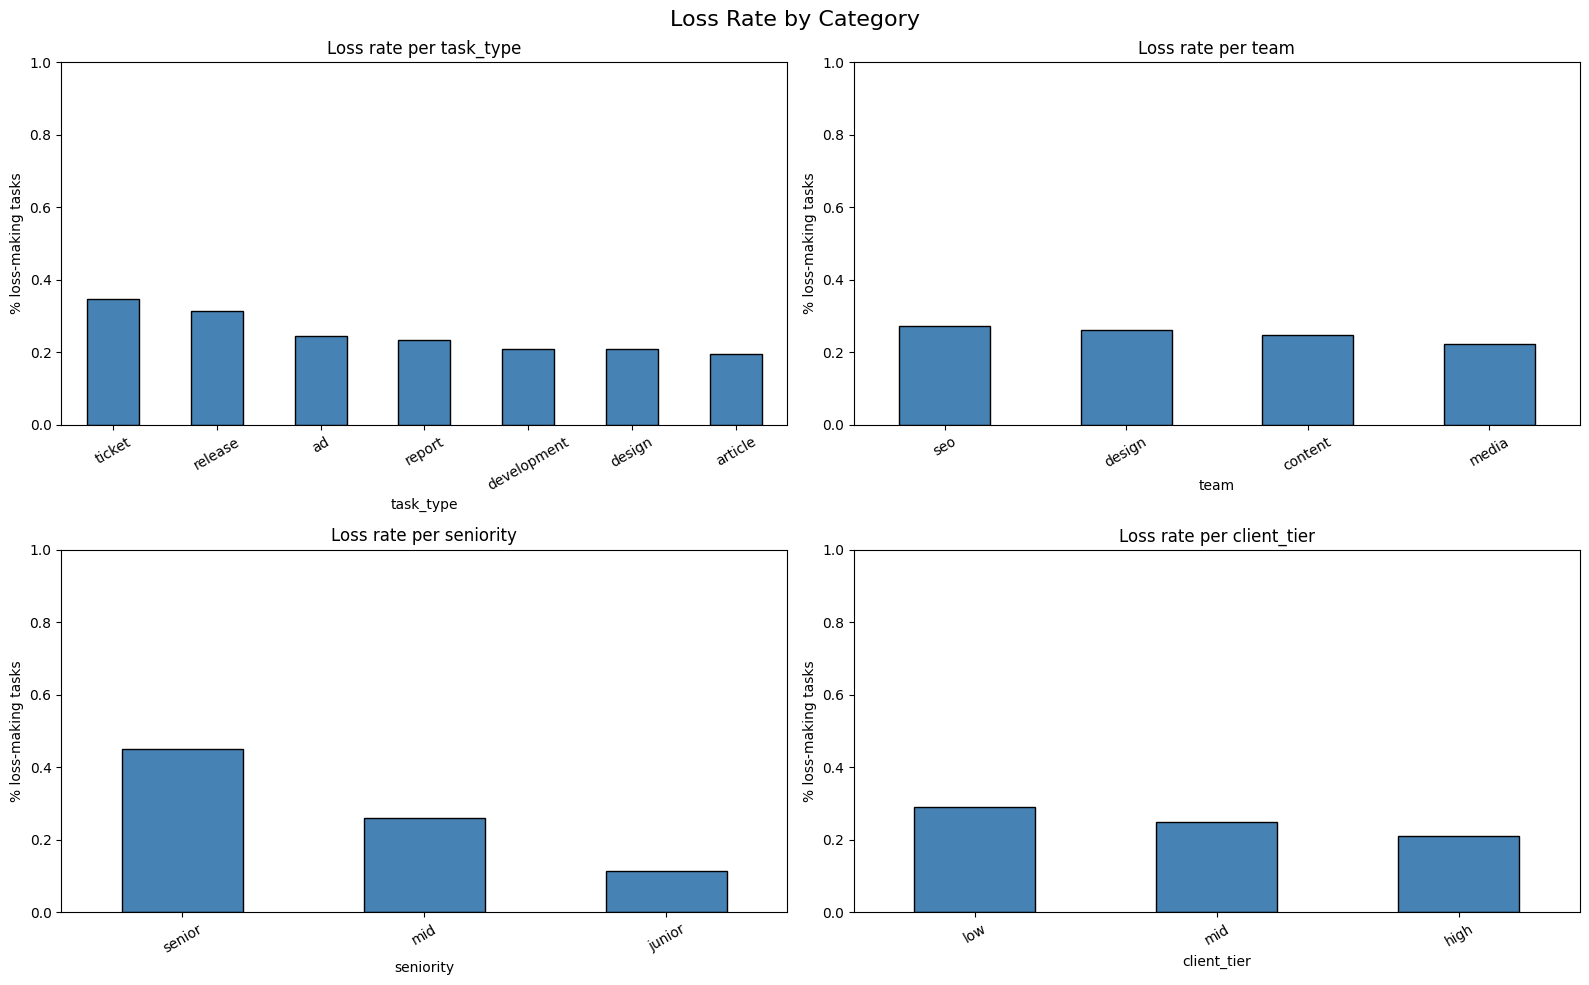

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flatten(), ["task_type", "team", "seniority", "client_tier"]):
    loss_rate = final_df.groupby(col)["is_loss"].mean().sort_values(ascending=False)
    loss_rate.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Loss rate per {col}")
    ax.set_ylabel("% loss-making tasks")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Loss Rate by Category", fontsize=16)
plt.tight_layout()
plt.show()

### Loss Rate by AI Group

A clear downward trend: the more AI is used, the fewer tasks end up 
losing money. Heavy AI users (75-100%) lose on only 12% of tasks, 
compared to 30% for low adopters, a more than 2x difference. 
Going all-in on AI is the single strongest predictor of avoiding losses.

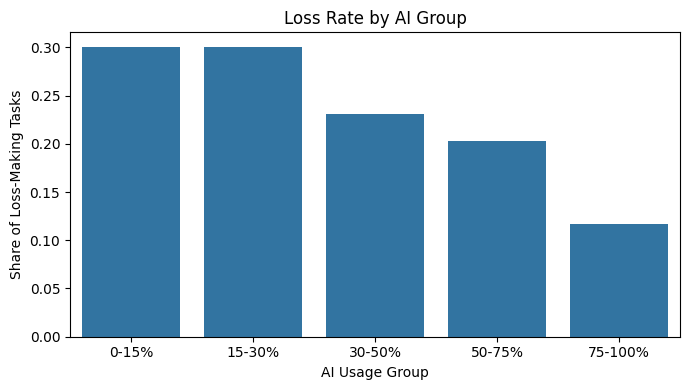

In [89]:
order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

ai_margin_df = final_df.groupby("ai_group", observed=True).agg(
    loss_rate=("is_loss", "mean")
).reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=ai_margin_df, x="ai_group", y="loss_rate", order=order)
plt.title("Loss Rate by AI Group")
plt.xlabel("AI Usage Group")
plt.ylabel("Share of Loss-Making Tasks")
plt.tight_layout()
plt.show()

### Loss Rate including previous estimates of `rework_hours`

Across all three rework cost estimates, higher AI usage consistently reduces the share of loss-making tasks, the 75-100% group performs best in every scenario.
As rework costs increase (from optimistic to pessimistic), the overall loss rate rises by roughly 10pp, but the pattern across AI groups remains stable.
This implies that AI-heavy workers generate fewer rework hours, which directly limits the damage when rework costs are assumed to be higher.

In [112]:
final_df["is_loss_optimistic"]   = (final_df["cost_ratio_optimistic"]   > 1).astype(int)
final_df["is_loss_normal"]       = (final_df["cost_ratio_normal"]       > 1).astype(int)
final_df["is_loss_pessimistic"]  = (final_df["cost_ratio_pessimistic"]  > 1).astype(int)

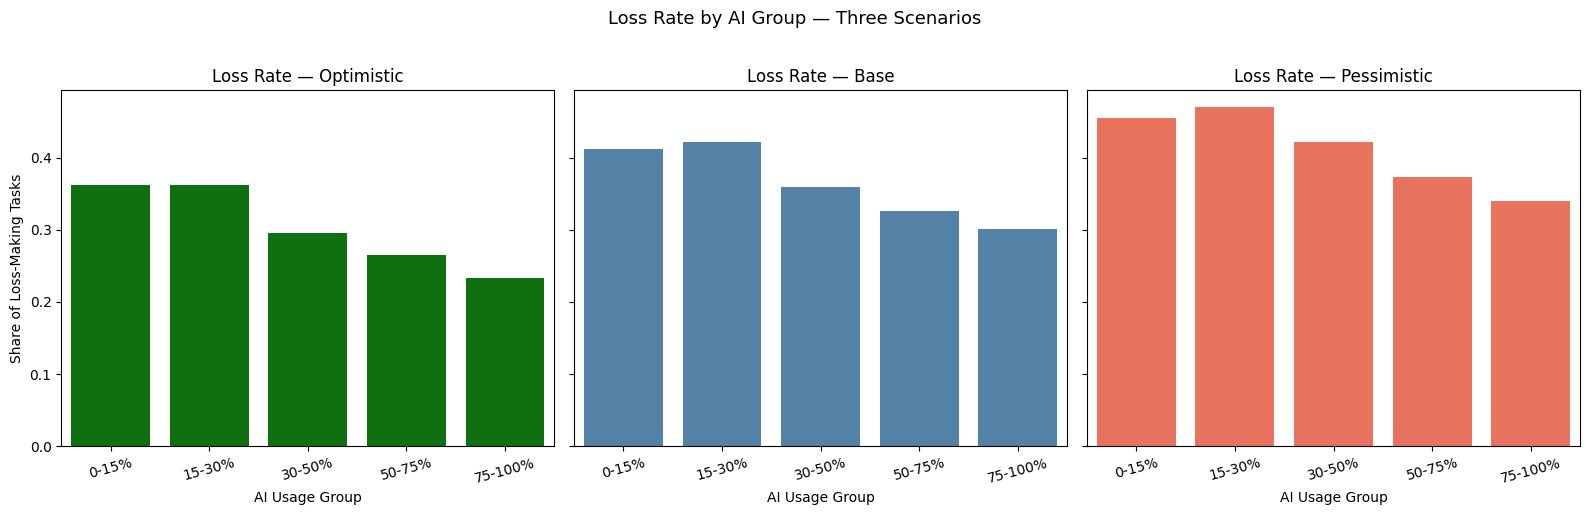

In [113]:
order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

ai_margin_df = final_df.groupby("ai_group", observed=True).agg(
    loss_rate_optimistic= ("is_loss_optimistic",  "mean"),
    loss_rate_normal=     ("is_loss_normal",       "mean"),
    loss_rate_pessimistic=("is_loss_pessimistic",  "mean")
).reset_index()

scenarios = [
    ("loss_rate_optimistic",  "Optimistic", "green"),
    ("loss_rate_normal",      "Base",       "steelblue"),
    ("loss_rate_pessimistic", "Pessimistic","tomato"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (col, label, color) in zip(axes, scenarios):
    sns.barplot(data=ai_margin_df, x="ai_group", y=col,
                order=order, color=color, ax=ax)
    ax.set_title(f"Loss Rate — {label}")
    ax.set_xlabel("AI Usage Group")
    ax.set_ylabel("Share of Loss-Making Tasks" if ax == axes[0] else "")
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Loss Rate by AI Group — Three Scenarios", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Cost Ratio by AI Group

Cost ratio drops steadily after the 15-30% peak, the familiar danger zone 
where AI adds overhead without yet delivering efficiency. Heavy AI users 
(75-100%) have the lowest cost ratio at 0.66, meaning they spend 
significantly less relative to revenue. AI, when fully adopted, is a 
genuine cost reduction tool.

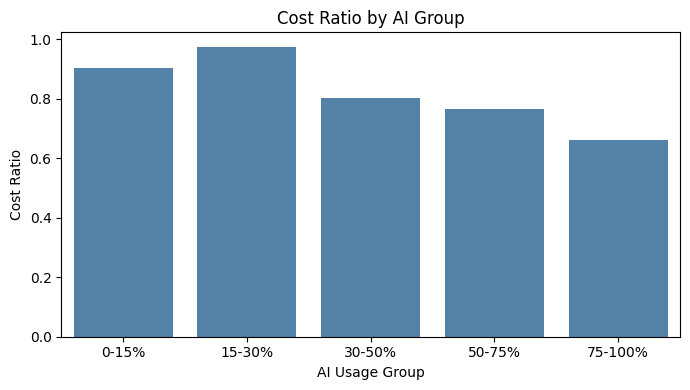

In [91]:
order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

plt.figure(figsize=(7, 4))
sns.barplot(data=final_df, x="ai_group", y="cost_ratio",
            order=order, errorbar=None, color="steelblue")
plt.title("Cost Ratio by AI Group")
plt.xlabel("AI Usage Group")
plt.ylabel("Cost Ratio")
plt.tight_layout()
plt.show()

### Cost Ratio including previous estimates of `rework_hours`

The 75-100% AI group consistently shows the lowest cost ratio across all scenarios, indicating better cost efficiency with higher AI adoption.

The 50-75% group is the most volatile, peaking at ≈1.85 in the Pessimistic scenario, suggesting high and uncertain rework exposure.

As rework costs increase (Optimistic → Pessimistic), differences between groups widen, amplifying the impact of AI usage on cost efficiency.

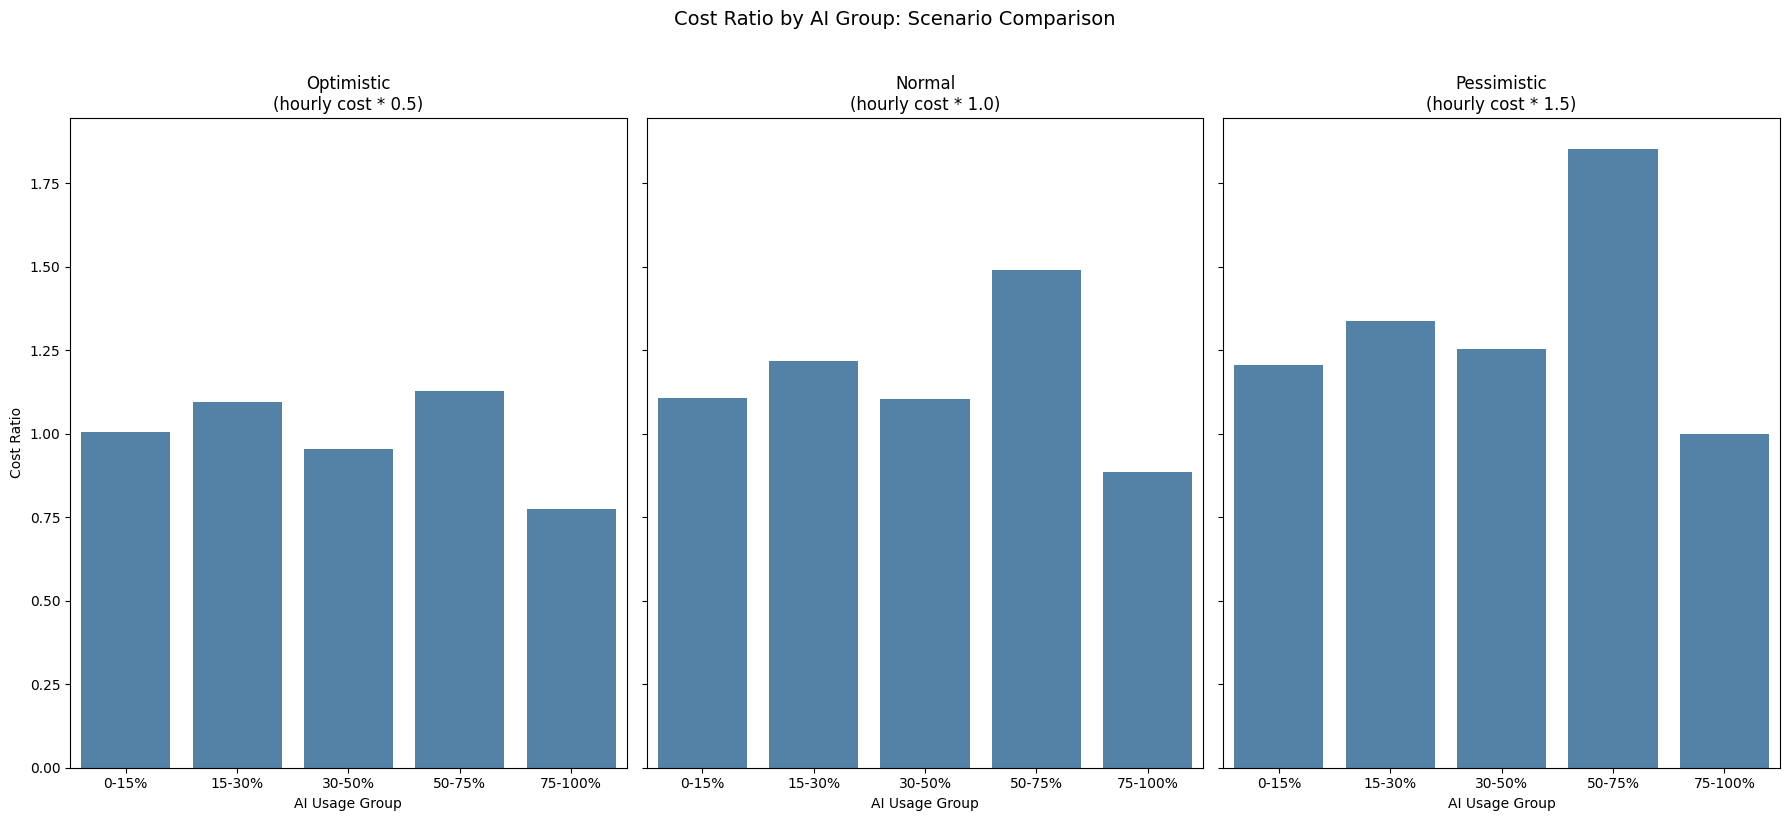

In [92]:
scenarios = [
    ("cost_ratio_optimistic", "Optimistic",   "steelblue",  "hourly cost * 0.5"),
    ("cost_ratio_normal",     "Normal",        "steelblue",  "hourly cost * 1.0"),
    ("cost_ratio_pessimistic","Pessimistic",   "steelblue",  "hourly cost * 1.5"),
]

order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

# sharey = True keeps the y-axis scale identical across all three panels

for ax, (col, title, color, subtitle) in zip(axes, scenarios):
    sns.barplot(
        data=final_df,
        x="ai_group",
        y=col,
        order=order,
        errorbar=None,
        color=color,
        ax=ax,
    )
    ax.set_title(f"{title}\n({subtitle})", fontsize=12)
    ax.set_xlabel("AI Usage Group")
    ax.set_ylabel("Cost Ratio" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Cost Ratio by AI Group: Scenario Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Outcome_score for ai_group
The bar chart shows that outcome score stays relatively stable across all groups 
(~65-70): AI usage alone doesn't move the needle on output quality.
The boxplot confirms this: variability is high in every group, meaning results 
depend more on the individual task or team than on how much AI is used.

/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/3230736408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x="ai_group", y="outcome_score",
/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/3230736408.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="outcome_score",


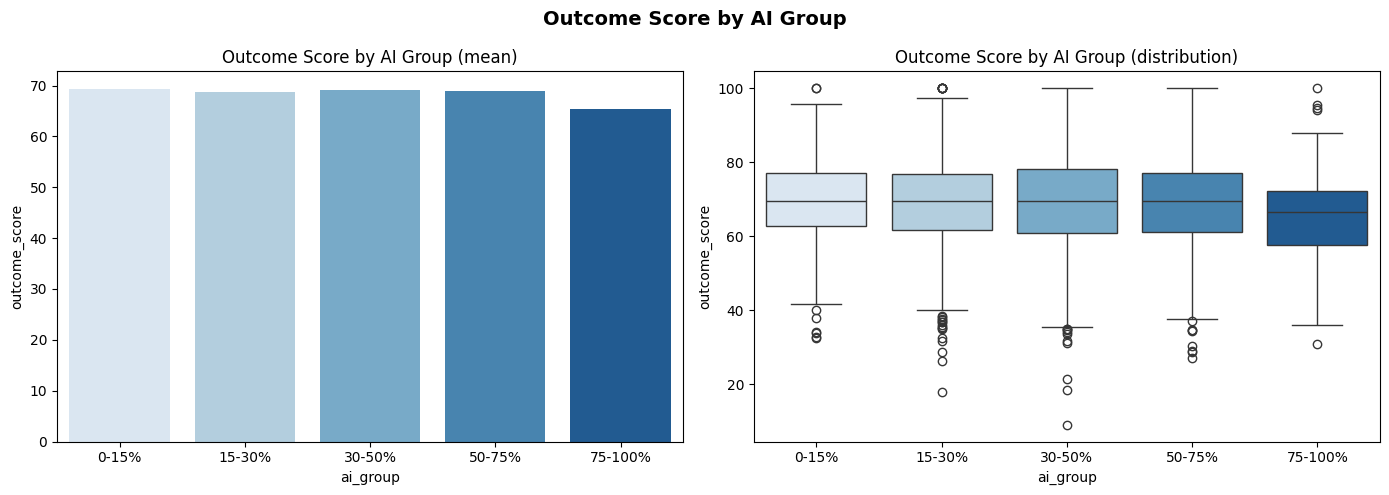

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

sns.barplot(data=final_df, x="ai_group", y="outcome_score",
            order=order, palette="Blues", errorbar=None, ax=axes[0])
axes[0].set_title("Outcome Score by AI Group (mean)")

sns.boxplot(data=final_df, x="ai_group", y="outcome_score",
            order=order, palette="Blues", ax=axes[1])
axes[1].set_title("Outcome Score by AI Group (distribution)")

plt.suptitle("Outcome Score by AI Group", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Error Rate by AI Group

Error rate peaks at 30-50% and drops at higher usage levels, consistent 
with our interpretation: partial adoption creates confusion, full adoption 
brings discipline. 
As we can see the 75-100% group doesn't reach the lowest 
error rate (that's 50-75%), infact because we are looking just at one variables keeping the others costant
this can bring to diminishing returns at the extreme.  

/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/724198027.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x="ai_group", y="error_rate",


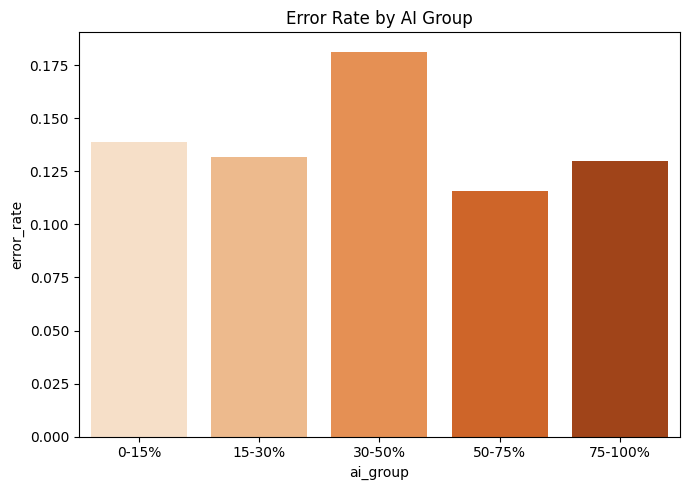

In [94]:
plt.figure(figsize=(7, 5))
order = ["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"]

sns.barplot(data=final_df, x="ai_group", y="error_rate",
            order=order, palette="Oranges", errorbar=None)
plt.title("Error Rate by AI Group")
plt.tight_layout()
plt.show()

### Revisions Rate by AI Group

Revisions peak at 30-50% and then fall consistently, so we deduct that the more 
committed teams are to AI, the less their work gets sent back. 

/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/3949555485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x="ai_group", y="revisions_rate",


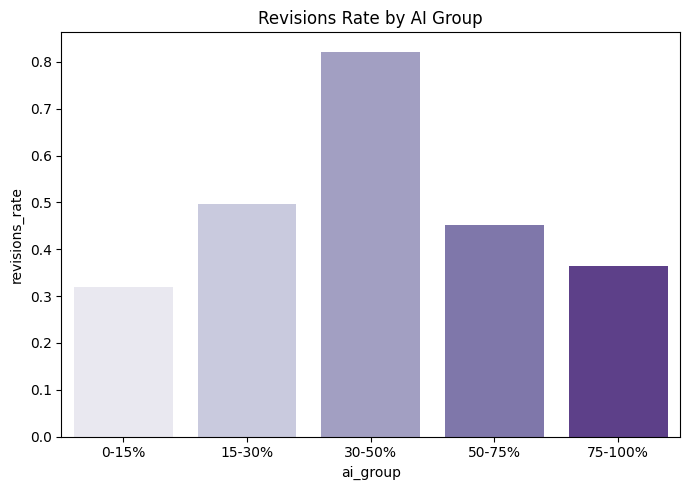

In [95]:
plt.figure(figsize=(7, 5))

sns.barplot(data=final_df, x="ai_group", y="revisions_rate",
            order=order, palette="Purples", errorbar=None)
plt.title("Revisions Rate by AI Group")
plt.tight_layout()
plt.show()

### Rework_ratio for ai_group
Rework ratio increases steadily with AI usage, from 0.14 to 0.25.
The more AI is used, the more work gets sent back, suggesting that heavy 
AI adoption may introduce quality issues that require additional review cycles.

/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/381750716.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x="ai_group", y="rework_ratio",
/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/381750716.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="rework_ratio",


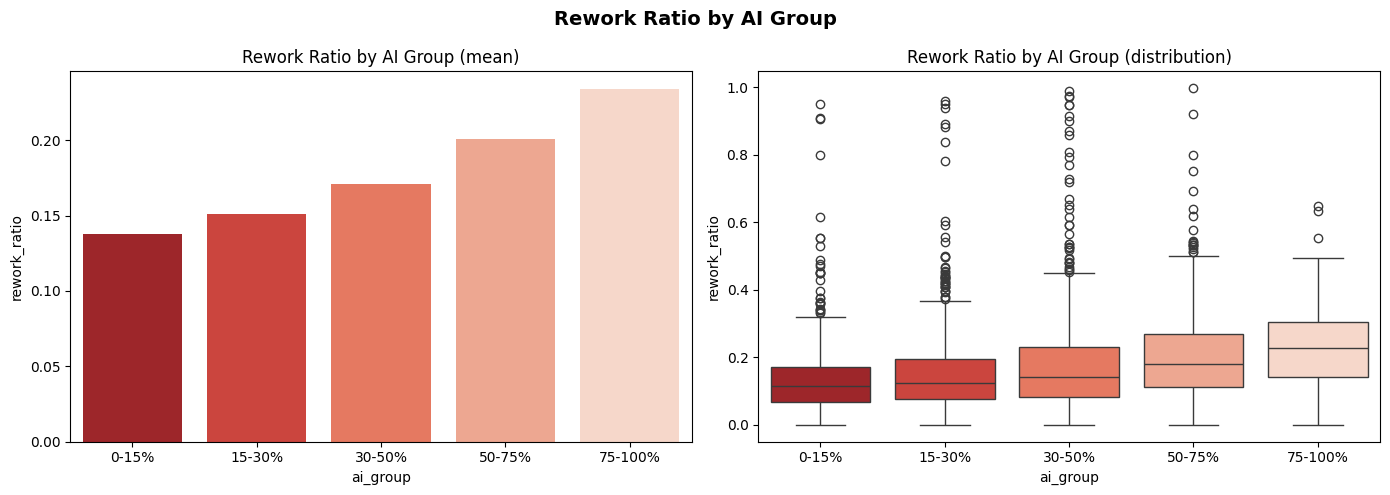

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=final_df, x="ai_group", y="rework_ratio",
            order=order, palette="Reds_r", errorbar=None, ax=axes[0])
axes[0].set_title("Rework Ratio by AI Group (mean)")

sns.boxplot(data=final_df, x="ai_group", y="rework_ratio",
            order=order, palette="Reds_r", ax=axes[1])
axes[1].set_title("Rework Ratio by AI Group (distribution)")

plt.suptitle("Rework Ratio by AI Group", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Rework Ratio vs Revisions Rate — A Counterintuitive Picture**

At first glance, these two metrics seem to tell opposite stories.

Revisions rate drops at high AI usage, teams are requesting fewer changes 
during the work process, suggesting they are getting things right earlier.

Rework ratio increases at high AI usage, yet more of the final output 
ends up being sent back after delivery.

## RQ3 - AI → quality or just speed?

#### T-test for speed

To test whether AI has an impact on delivery speed we use a two-sample t-test for continuous
metrics (hours spent, delivery time) and a chi-square test for SLA breach, which is the appropriate
choice for binary variables.

The results here are probably the clearest signal in the analysis. Delivery time is highly
significant (p < 0.01), AI-assisted tasks are delivered faster on average (4.43 vs 4.91 days).
SLA breach tells the same story: AI-assisted tasks breach the SLA 38% of the time compared to 47%
for non-assisted ones, a difference significant at all three levels. Hours spent, on the other hand,
shows virtually no difference between the two groups, which suggests AI is not reducing the effort
put into a task but is helping teams deliver within tighter deadlines. Speed gains appear to be
real and statistically robust.

In [97]:
from scipy.stats import chi2_contingency

speed_metrics = [
    ("hours_spent",   "Hours Spent"),
    ("delivery_time", "Delivery Time"),
]
for metric, label in speed_metrics:
    m_on  = ai_on[metric].mean()
    m_off = ai_off[metric].mean()
    t_stat, p_val = stats.ttest_ind(ai_on[metric].dropna(), ai_off[metric].dropna())
    print(f"{label}")
    print(f"  AI assisted: {m_on:.2f}  |  No AI: {m_off:.2f}")
    print(f"  t-test p={p_val:.4f}")
    print(f"    α=0.10 -> {'Significant' if p_val < 0.10 else 'Not significant'}")
    print(f"    α=0.05 -> {'Significant' if p_val < 0.05 else 'Not significant'}")
    print(f"    α=0.01 -> {'Significant' if p_val < 0.01 else 'Not significant'}\n")

#chi-square test because it is a dummy variable
ct = pd.crosstab(final_df["ai_assisted"], final_df["sla_breach"])
chi2, p_val, dof, expected = chi2_contingency(ct)

breach_on  = ai_on["sla_breach"].mean()
breach_off = ai_off["sla_breach"].mean()

print("SLA Breach")
print(f"  AI assisted: {breach_on:.1%}  |  No AI: {breach_off:.1%}")
print(f"  chi-square p={p_val:.4f}")
print(f"    α=0.10 -> {'Significant' if p_val < 0.10 else 'Not significant'}")
print(f"    α=0.05 -> {'Significant' if p_val < 0.05 else 'Not significant'}")
print(f"    α=0.01 -> {'Significant' if p_val < 0.01 else 'Not significant'}\n")

Hours Spent
  AI assisted: 13.00  |  No AI: 13.15
  t-test p=0.8121
    α=0.10 -> Not significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant

Delivery Time
  AI assisted: 4.43  |  No AI: 4.91
  t-test p=0.0000
    α=0.10 -> Significant
    α=0.05 -> Significant
    α=0.01 -> Significant

SLA Breach
  AI assisted: 38.1%  |  No AI: 47.4%
  chi-square p=0.0006
    α=0.10 -> Significant
    α=0.05 -> Significant
    α=0.01 -> Significant



#### T-test for quality metrics
`outcome_score` shows no statistically significant difference between AI-assisted == True and AI-assisted == False (p=0.597).
The values are virtually identical:
- AI assisted: 68.86
- No AI: 69.21

a gap of less than 0.4 points on a 0–100 scale.

This suggests AI usage has no measurable impact on output quality, at least as captured by outcome score alone.

In [98]:
quality_metrics = [("outcome_score", "Outcome Score")]

print("QUALITY ANALYSIS - Where Does AI Help?\n")

for metric, label in quality_metrics:
    m_on  = ai_on[metric].mean()
    m_off = ai_off[metric].mean()
    t_stat, p_val = stats.ttest_ind(ai_on[metric].dropna(), ai_off[metric].dropna())
    print(f"{label}")
    print(f"  AI assisted: {m_on:.2f}  |  No AI: {m_off:.2f}")
    print(f"  t-test p={p_val:.4f}")
    print(f"    α=0.10 -> {'Significant' if p_val < 0.10 else 'Not significant'}")
    print(f"    α=0.05 -> {'Significant' if p_val < 0.05 else 'Not significant'}")
    print(f"    α=0.01 -> {'Significant' if p_val < 0.01 else 'Not significant'}\n")

QUALITY ANALYSIS - Where Does AI Help?

Outcome Score
  AI assisted: 68.86  |  No AI: 69.21
  t-test p=0.5969
    α=0.10 -> Not significant
    α=0.05 -> Not significant
    α=0.01 -> Not significant



#### Quality vs Speed Decomposition

`speed_index` remains stable and slightly improves as AI usage increases, staying consistently around 0.75–0.80 across all groups.

`quality_index` shows a clear negative trend, dropping from 0.53 in the lowest AI usage group down to 0.39 in the highest (75–100%).

Higher AI usage appears to maintain delivery speed but comes at the cost of output quality, workers relying most on AI are faster but produce lower quality outcomes.

          quality_index  speed_index
ai_group                            
0-15%          0.524569     0.749100
15-30%         0.505913     0.747232
30-50%         0.489437     0.772059
50-75%         0.456815     0.794880
75-100%        0.384890     0.799260


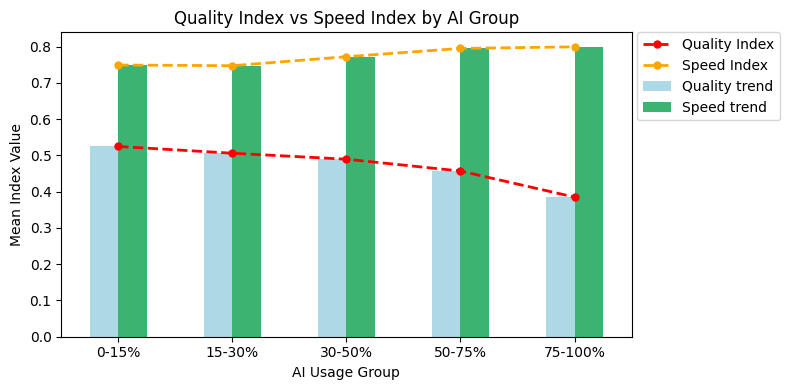

In [99]:
final_df["sla_ratio"] = final_df["delivery_time"] / final_df["sla_days"]

final_df["outcome_norm"] = (final_df["outcome_score"] - final_df["outcome_score"].min()) / (final_df["outcome_score"].max() - final_df["outcome_score"].min())
final_df["rework_norm"] = (final_df["rework_ratio"] - final_df["rework_ratio"].min()) / (final_df["rework_ratio"].max() - final_df["rework_ratio"].min())
final_df["quality_index"] = final_df["outcome_norm"] - final_df["rework_norm"]

final_df["sla_ratio_norm"] = (final_df["sla_ratio"] - final_df["sla_ratio"].min()) / (final_df["sla_ratio"].max() - final_df["sla_ratio"].min())
final_df["speed_index"] = 1 - final_df["sla_ratio_norm"]

qs_summary = final_df.groupby("ai_group", observed=True)[["quality_index", "speed_index"]].mean()
print(qs_summary)

ax = qs_summary.plot(kind="bar", figsize=(8, 4), rot=0, color=["lightblue", "mediumseagreen"])
x = range(len(qs_summary))
ax.plot(x, qs_summary["quality_index"].values, color="red", linewidth=2, marker="o", markersize=5, linestyle="--")
ax.plot(x, qs_summary["speed_index"].values, color="orange", linewidth=2, marker="o", markersize=5, linestyle="--")

plt.title("Quality Index vs Speed Index by AI Group")
plt.ylabel("Mean Index Value")
plt.xlabel("AI Usage Group")
plt.legend(["Quality Index", "Speed Index", "Quality trend", "Speed trend"],bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

## RQ4 - When does it become negative? 

#### Critical Threshold — When Does AI Start Hurting the Margin?

To smooth out the noise in the raw data we use a rolling average, which simply computes the
mean profit margin within a sliding window of 500 observations sorted by AI usage. This makes
the underlying trend readable without making any statistical assumption.

The margin briefly turns negative around 20% usage, which is the critical threshold the
analysis was looking for. Below that, teams working traditionally hold a stable margin around
6%. Above 30% the margin recovers steadily and keeps growing, stabilizing around 30% at high
usage levels. The takeaway is simple: partial AI adoption is the riskiest configuration,
committing to it fully is consistently more profitable than using it only marginally.

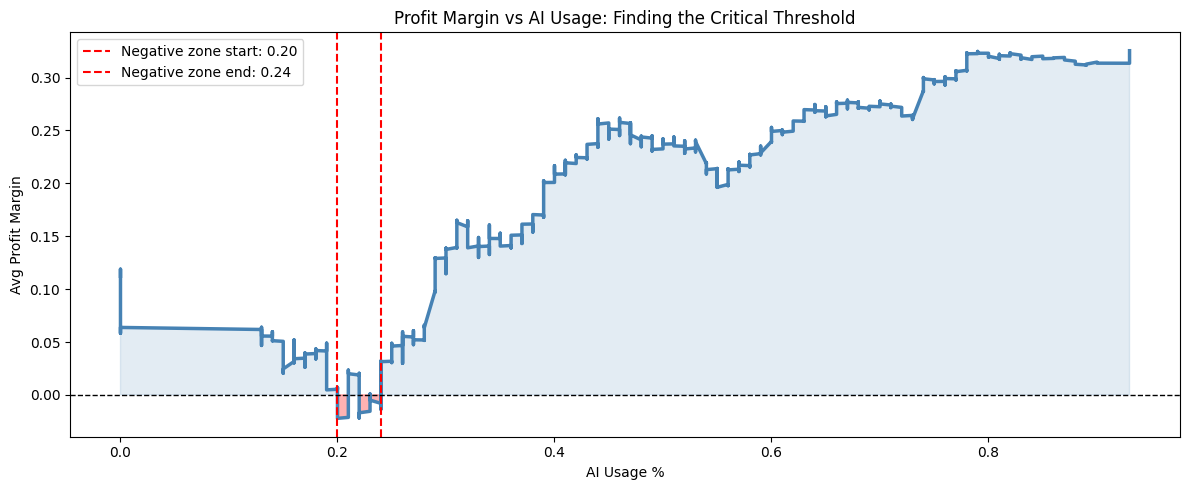

In [100]:
df_thresh = final_df[['ai_usage_pct', 'profit_margin']].dropna().sort_values('ai_usage_pct')

window = 500
rolling_margin = df_thresh['profit_margin'].rolling(window, center=True, min_periods=30).mean()

# find the x range where margin is negative
negative_mask = rolling_margin < 0
negative_x = df_thresh['ai_usage_pct'][negative_mask.values]

x_start = negative_x.min()
x_end = negative_x.max()

plt.figure(figsize=(12, 5))
plt.plot(df_thresh['ai_usage_pct'], rolling_margin, color='steelblue', lw=2.5)

# positive zone — blue
plt.fill_between(df_thresh['ai_usage_pct'], rolling_margin, 0,
                 where=(rolling_margin >= 0), alpha=0.15, color='steelblue')

# negative zone — red
plt.fill_between(df_thresh['ai_usage_pct'], rolling_margin, 0,
                 where=(rolling_margin < 0), alpha=0.3, color='red')

# vertical dashed lines at the edges of the negative zone
plt.axvline(x_start, color='red', linestyle='--', lw=1.5, label=f'Negative zone start: {x_start:.2f}')
plt.axvline(x_end, color='red', linestyle='--', lw=1.5, label=f'Negative zone end: {x_end:.2f}')

plt.axhline(0, color='black', lw=1, linestyle='--')
plt.xlabel('AI Usage %')
plt.ylabel('Avg Profit Margin')
plt.title('Profit Margin vs AI Usage: Finding the Critical Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## Adavanced RQ1 - Speed vs Quality Trade-off

The scatter plot and Pearson correlation (r = 0.002, p = 0.891) 
show no relationship between `speed_index` and `quality_index`. 
Delivering faster does not compromise output quality, and 
higher quality does not require more time.

Decision: there is no speed-quality trade-off to manage in this 
dataset. Speed and quality are independent dimensions, 
optimizing for one does not harm the other. Efforts to improve 
delivery speed can be pursued 
without concern for quality degradation.

Correlation: -0.0210, p = 0.2332


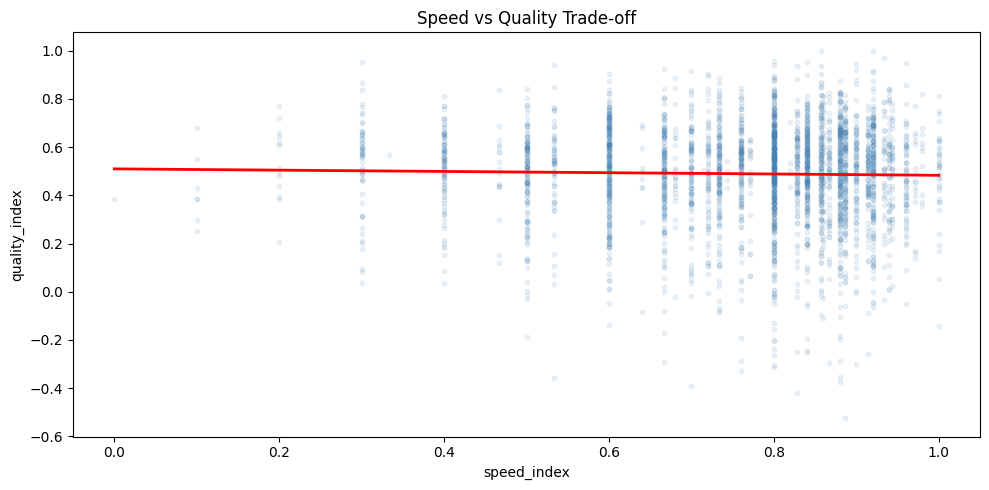

In [101]:
from scipy.stats import pearsonr

corr, p = pearsonr(final_df["speed_index"], final_df["quality_index"])
print(f"Correlation: {corr:.4f}, p = {p:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(final_df["speed_index"], final_df["quality_index"],
            alpha=0.1, s=10, color="steelblue")
m, b = np.polyfit(final_df["speed_index"], final_df["quality_index"], 1)
x_line = np.linspace(0, 1, 100)
plt.plot(x_line, m*x_line + b, color="red", linewidth=2)
plt.xlabel("speed_index")
plt.ylabel("quality_index")
plt.title("Speed vs Quality Trade-off")
plt.tight_layout()
plt.show()

## Advanced RQ2 — Rework Threshold

The scatter plot and Pearson correlation (r = 0.008, p = 0.638) 
show no significant relationship between `rework_ratio` and 
`profit_margin`. Rework does not destroy profit margin,
a finding consistent with RQ2, where loss-making tasks were 
shown to have lower rework than profitable ones.

Decision: there is no rework threshold to monitor. Rework is 
not a financial risk indicator in this dataset. The focus for 
margin protection should remain on pricing and cost estimation 
(cost_ratio), not on rework reduction.

Correlazione: 0.0519, p = 0.0031


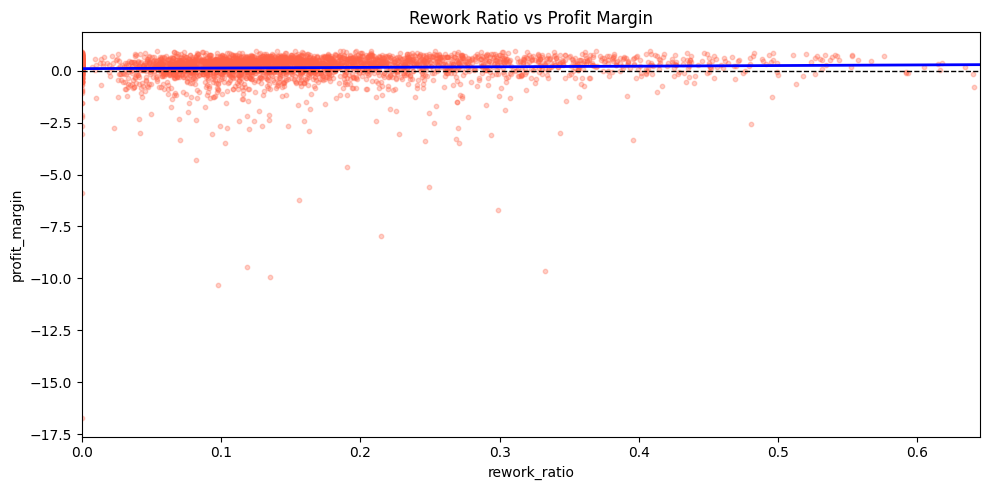

In [102]:
corr, p = pearsonr(final_df["rework_ratio"], final_df["profit_margin"])
print(f"Correlazione: {corr:.4f}, p = {p:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(final_df["rework_ratio"], final_df["profit_margin"],
            alpha=0.3, s=10, color="tomato")
m, b = np.polyfit(final_df["rework_ratio"], final_df["profit_margin"], 1)
x_line = np.linspace(0, final_df["rework_ratio"].quantile(0.99), 100)
plt.plot(x_line, m*x_line + b, color="blue", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlim(0, final_df["rework_ratio"].quantile(0.99))
plt.xlabel("rework_ratio")
plt.ylabel("profit_margin")
plt.title("Rework Ratio vs Profit Margin")
plt.tight_layout()
plt.show()

Across all three rework cost scenarios, higher rework ratio is weakly but consistently associated with lower profit margins, the trend line slopes slightly negative in every case.
The pessimistic scenario shows the steepest decline, with the regression line visibly diverging from zero as rework ratio increases, confirming that rework cost assumptions amplify margin erosion.
The vast majority of observations cluster near zero, suggesting rework ratio alone is not a strong standalone predictor of profit margin, other variables likely interact with it.

Optimistic — Correlation: -0.1828, p = 0.0000


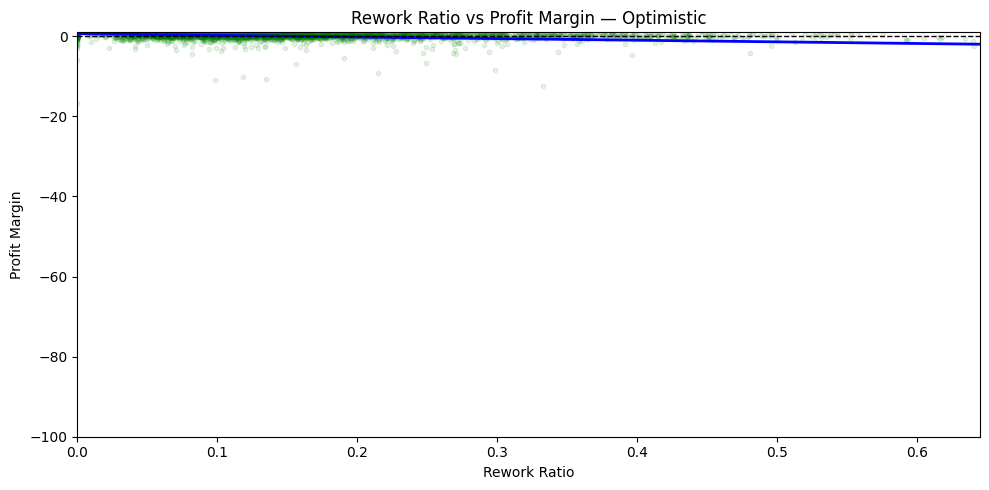

Base — Correlation: -0.1951, p = 0.0000


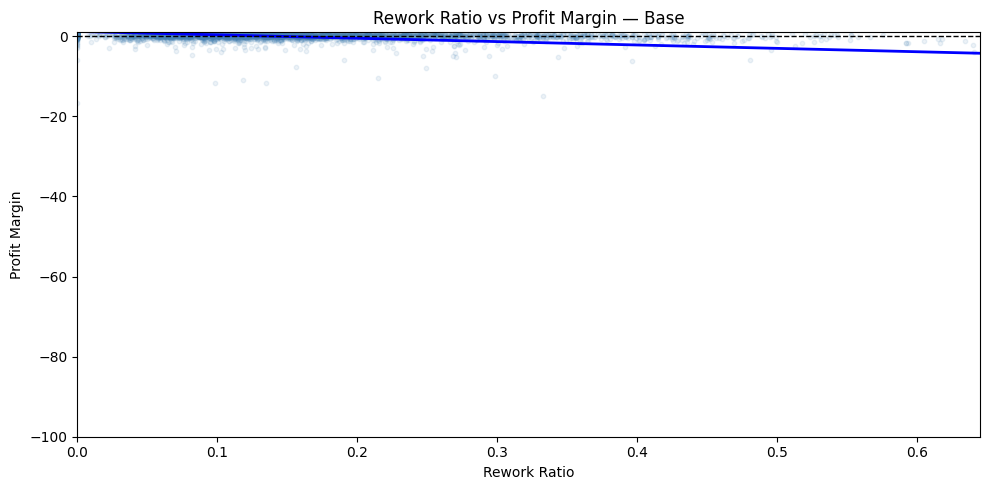

Pessimistic — Correlation: -0.1986, p = 0.0000


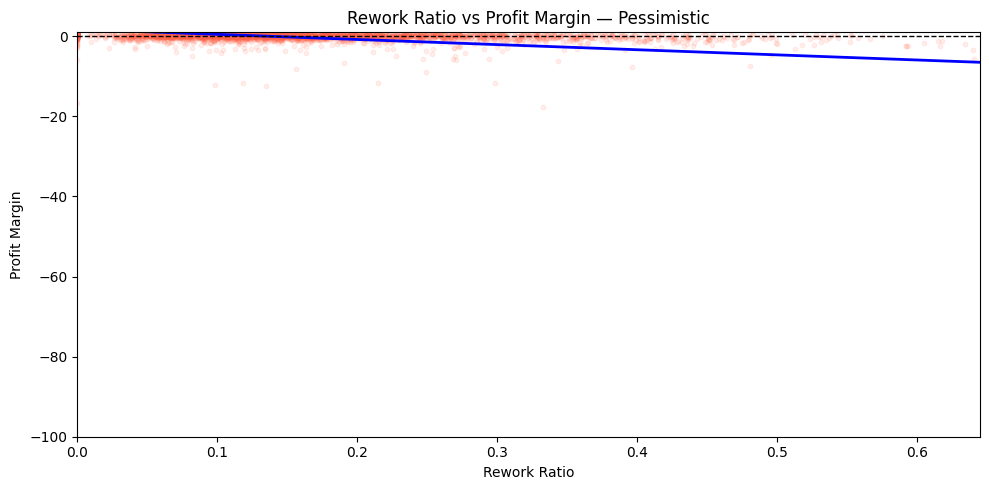

In [120]:
scenarios = [
    ("profit_margin_optimistic",  "Optimistic", "green"),
    ("profit_margin_normal",      "Base",       "steelblue"),
    ("profit_margin_pessimistic", "Pessimistic","tomato"),
]

for col, label, color in scenarios:
    corr, p = pearsonr(final_df["rework_ratio"].dropna(), final_df[col].dropna())
    print(f"{label} — Correlation: {corr:.4f}, p = {p:.4f}")

    plt.figure(figsize=(10, 5))
    plt.scatter(final_df["rework_ratio"], final_df[col],
                alpha=0.1, s=10, color=color)

    m, b = np.polyfit(final_df["rework_ratio"].dropna(), final_df[col].dropna(), 1)
    x_line = np.linspace(0, final_df["rework_ratio"].quantile(0.99), 100)
    plt.plot(x_line, m*x_line + b, color="blue", linewidth=2)

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xlim(0, final_df["rework_ratio"].quantile(0.99))
    plt.ylim(-100, 1)
    plt.xlabel("Rework Ratio")
    plt.ylabel("Profit Margin")
    plt.title(f"Rework Ratio vs Profit Margin — {label}")
    plt.tight_layout()
    plt.show()

## Advanced Q3 - AI → Real Profit?

#### Hourly Model : Sustainability Analysis

We investigated when the hourly pricing model becomes unsustainable by comparing it 
against fixed and value_based across six potential loss drivers (rework, errors, complexity, 
hours spent, billable hours, seniority). Only **seniority** showed a clear signal.

Breaking down hourly profit margin by seniority and AI usage group revealed that 
**senior workers drive the collapse**: they are expensive but AI makes them faster, 
resulting in fewer billable hours and negative margins across almost all AI usage groups. 
Junior workers never collapse; mid-level workers go negative between 15–75% AI usage.

**Conclusion:** the hourly model is structurally unsustainable for senior workers 
below 75% AI usage, and should be replaced with fixed or value_based pricing for that segment.

/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/643189307.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", ax=ax, palette=["salmon", "lightblue"])
/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/643189307.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", ax=ax, palette=["salmon", "lightblue"])
/var/folders/nc/11cnkb950sl13400hwjv35vm0000gn/T/ipykernel_20957/643189307.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_d

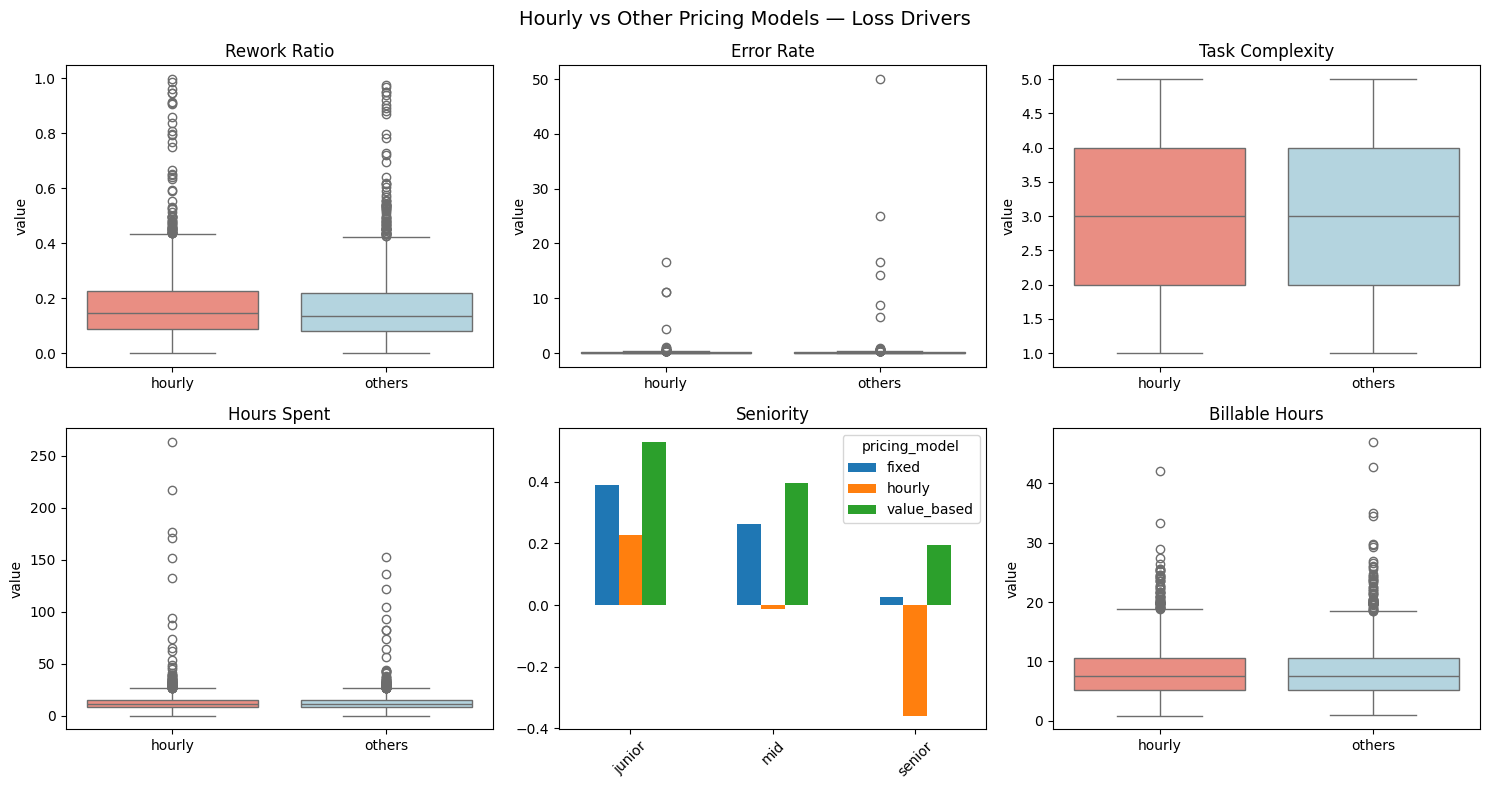

In [117]:
hourly = final_df[final_df["pricing_model"] == "hourly"]
others = final_df[final_df["pricing_model"] != "hourly"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Hourly vs Other Pricing Models — Loss Drivers", fontsize=14)

vars_to_check = [
    ("rework_ratio", "Rework Ratio"),
    ("error_rate", "Error Rate"),
    ("task_complexity_score", "Task Complexity"),
    ("hours_spent", "Hours Spent"),
    ("seniority", "Seniority"),
    ("billable_hours", "Billable Hours"),
]

for ax, (col, title) in zip(axes.flatten(), vars_to_check):
    if final_df[col].dtype == "object" or col == "seniority":
        # categorical: profit margin medio per categoria, separato per pricing
        temp = final_df[final_df["pricing_model"].isin(["hourly", "fixed", "value_based"])]
        temp.groupby(["pricing_model", col])["profit_margin"].mean().unstack(0).plot(
            kind="bar", ax=ax, rot=45
        )
    else:
        # numeric: boxplot hourly vs altri
        plot_df = pd.DataFrame({
            "value": pd.concat([hourly[col], others[col]]),
            "group": ["hourly"] * len(hourly) + ["others"] * len(others)
        })
        sns.boxplot(data=plot_df, x="group", y="value", ax=ax, palette=["salmon", "lightblue"])
    
    ax.set_title(title)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

#### Seniority Case

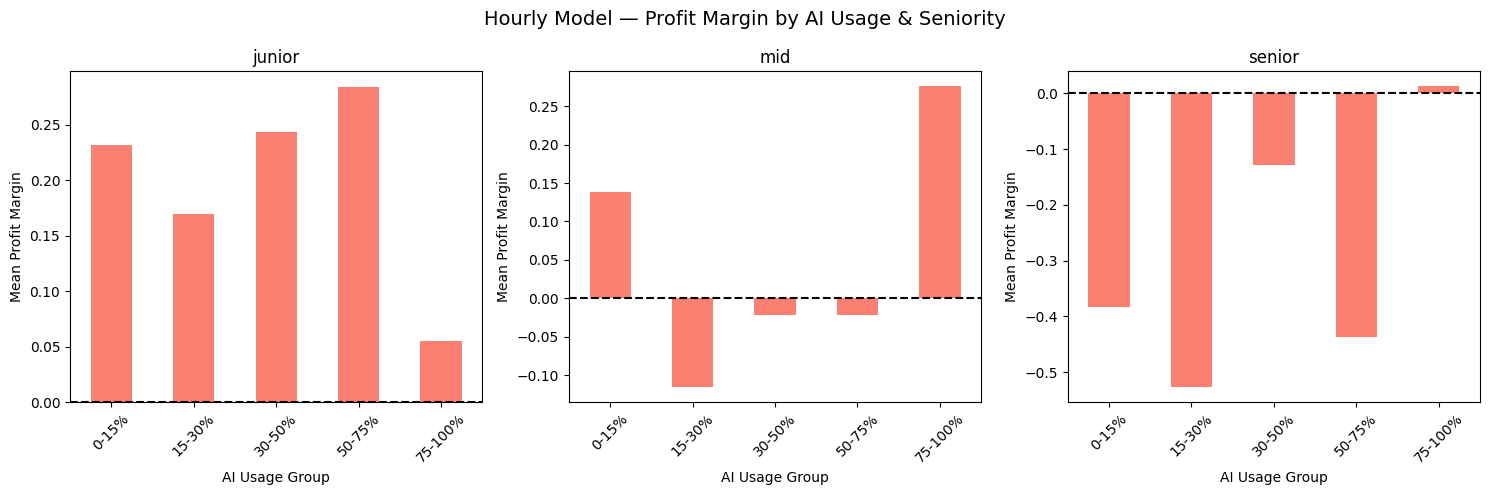

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Hourly Model — Profit Margin by AI Usage & Seniority", fontsize=14)

seniority_levels = ["junior", "mid", "senior"]

for ax, level in zip(axes, seniority_levels):
    subset = final_df[(final_df["pricing_model"] == "hourly") & (final_df["seniority"] == level)]
    subset.groupby("ai_group", observed=True)["profit_margin"].mean().plot(
        kind="bar", ax=ax, color="salmon", rot=45
    )
    ax.axhline(y=0, color="black", linewidth=1.5, linestyle="--")
    ax.set_title(level)
    ax.set_xlabel("AI Usage Group")
    ax.set_ylabel("Mean Profit Margin")

plt.tight_layout()
plt.show()